# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [76]:
# Installing specific library versions for stable model training and reproducible results across environments.
# This prevents version mismatches in NumPy, pandas, scikit‑learn, XGBoost, and other core dependencies.
!pip install \
    numpy==1.26.4 \
    pandas==2.2.2 \
    scikit-learn==1.4.2 \
    matplotlib==3.8.0 \
    seaborn==0.13.2 \
    joblib==1.4.2 \
    xgboost==2.1.1 \
    requests==2.32.3 \
    huggingface_hub==0.23.0 \
    -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 87.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 130.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [77]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [79]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [294]:
# Read the primary SuperKart sales dataset from the mounted Google Drive directory
# This CSV file contains historical product-level and store-level attributes along with sales totals
kart = pd.read_csv("/content/drive/MyDrive/Superkart/SuperKart.csv")

In [90]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

In [295]:
# Read the primary Batch_Data_Supekart dataset from the mounted Google Drive directory
batchkart = pd.read_csv("/content/drive/MyDrive/Superkart/Batch_Data_SuperKart.csv")
# copying data to another variable to avoid any changes to original data
data1 = batchkart.copy()

# **Data Overview**

In [296]:
# Display the first 5 rows of the dataset loaded from `SuperKart.csv`
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [297]:
# Display the last 5 rows of the dataset loaded from `SuperKart.csv`
data.tail()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
8758,14.80,No Sugar,0.016,140.53,Medium,Tier 2,Supermarket Type2,3806.53,NC,16,Non Perishables
8759,14.06,No Sugar,0.142,144.51,Medium,Tier 2,Supermarket Type2,5020.74,NC,16,Non Perishables
8760,13.48,No Sugar,0.017,88.58,High,Tier 2,Supermarket Type1,2443.42,NC,38,Non Perishables
8761,13.89,No Sugar,0.193,168.44,High,Tier 2,Supermarket Type1,4171.82,NC,38,Non Perishables
8762,14.73,Low Sugar,0.177,224.93,Small,Tier 3,Food Mart,2186.08,FD,27,Non Perishables


In [95]:
# Display the first five records to preview the dataset structure and feature values.
# Verify that the data has been loaded correctly before starting exploratory analysis.

print('Displaying the first 5 rows of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:')
display(batchkart.head())



Displaying the first 5 rows of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables


In [96]:

# Display the last five records to preview the dataset structure and feature values.
# Verify that the data has been loaded correctly before starting exploratory analysis.

print('Displaying the last 5 rows of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:')
display(batchkart.tail())

Displaying the last 5 rows of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
5,10.00,No Sugar,0.050,92.40,High,Tier 1,Supermarket Type1,NC,5,Non Perishables
6,7.85,Regular,0.018,178.90,Small,Tier 3,Supermarket Type2,FD,19,Perishables
7,14.10,Low Sugar,0.041,63.25,Medium,Tier 2,Food Mart,DR,27,Perishables
8,3.50,No Sugar,0.009,250.00,High,Tier 1,Departmental Store,NC,10,Non Perishables
9,11.25,Regular,0.055,130.45,Small,Tier 3,Supermarket Type3,FD,14,Perishables


## Understand the shape of the dataset

## Check the data types of the columns for the dataset

In [97]:
# Display dataset structure, column names, data types, and non-null value counts from `SuperKart.csv`
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [98]:
# Helps identify missing values and verify data types before analysis and preprocessing

print('Displaying the info of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:')
display(batchkart.info())

Displaying the info of batchkart DataFrame loaded from `Batch_Data_SuperKart.csv`:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_Weight            10 non-null     float64
 1   Product_Sugar_Content     10 non-null     object 
 2   Product_Allocated_Area    10 non-null     float64
 3   Product_MRP               10 non-null     float64
 4   Store_Size                10 non-null     object 
 5   Store_Location_City_Type  10 non-null     object 
 6   Store_Type                10 non-null     object 
 7   Product_Id_char           10 non-null     object 
 8   Store_Age_Years           10 non-null     int64  
 9   Product_Type_Category     10 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 932.0+ bytes


None

## Statistical summary of the data
Let's check the statistical summary of the data of `SuperKart.csv`.

In [99]:
# Comprehensive statistical summary of the data DataFrame `SuperKart.csv`.
# Gives you a quick overview of the central tendency, dispersion, and shape of the dataset's distribution, as well as insights into categorical data.
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Statistical summary of the batch data
Let's check the statistical summary of the batch data loaded from `Batch_Data_SuperKart.csv`.

In [100]:
# Comprehensive statistical summary of the batchkart DataFrame `Batch_Data_SuperKart.csv`.
# Gives you a quick overview of the central tendency, dispersion, and shape of the dataset's distribution, as well as insights into categorical data.
batchkart.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Weight,10.0,NaN,NaN,NaN,10.801,4.747597,3.5,7.9375,10.625,13.74,19.3
Product_Sugar_Content,10,3,Regular,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,10.0,NaN,NaN,NaN,0.035,0.018098,0.009,0.02025,0.037,0.04875,0.06
Product_MRP,10.0,NaN,NaN,NaN,132.913,64.188973,55.2,87.225,123.765,170.575,250.0
Store_Size,10,3,Small,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,10,3,Tier 1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,10,5,Supermarket Type1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Id_char,10,3,FD,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Age_Years,10.0,NaN,NaN,NaN,16.3,8.179242,5.0,10.5,15.0,21.25,30.0
Product_Type_Category,10,2,Perishables,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# Checking for duplicate values `SuperKart.csv.`
data.duplicated().sum()

np.int64(0)

In [102]:
# Checking for duplicate values `Batch_Data_SuperKart.csv.`
batchkart.duplicated().sum()

np.int64(0)

In [103]:
# checking for missing values in the data for `SuperKart.csv.`
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [104]:
# checking for missing values in the data for `Batch_Data_SuperKart.csv.`
batchkart.isnull().sum()

,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_MRP,0
Store_Size,0
Store_Location_City_Type,0
Store_Type,0
Product_Id_char,0
Store_Age_Years,0
Product_Type_Category,0


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [105]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [106]:
# Function to create bar plots with percentage labels
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage labels.

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default False)
    n: displays the top n most frequent values for categorical data (default None)
    """
    plt.figure(figsize=(10, 6))
    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:  # If n is not specified, plot all unique values
        ax = sns.countplot(data=data, x=feature, palette='viridis', order=data[feature].value_counts().index)
    else:  # If n is specified, plot the top n unique values
        top_n_values = data[feature].value_counts().head(n).index
        ax = sns.countplot(data=data, x=feature, palette='viridis', order=top_n_values)

    plt.xticks(rotation=45, ha='right')

    for p in ax.patches:
        height = p.get_height()
        if perc:
            label = f'{height / total:.1%}'
        else:
            label = f'{int(height)}'
        ax.annotate(label, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=12, color='black')

    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Count' if not perc else 'Percentage', fontsize=12)
    plt.tight_layout()
    plt.show()

### Univariate Analysis of `Product_Sugar_Content` in `data` DataFrame

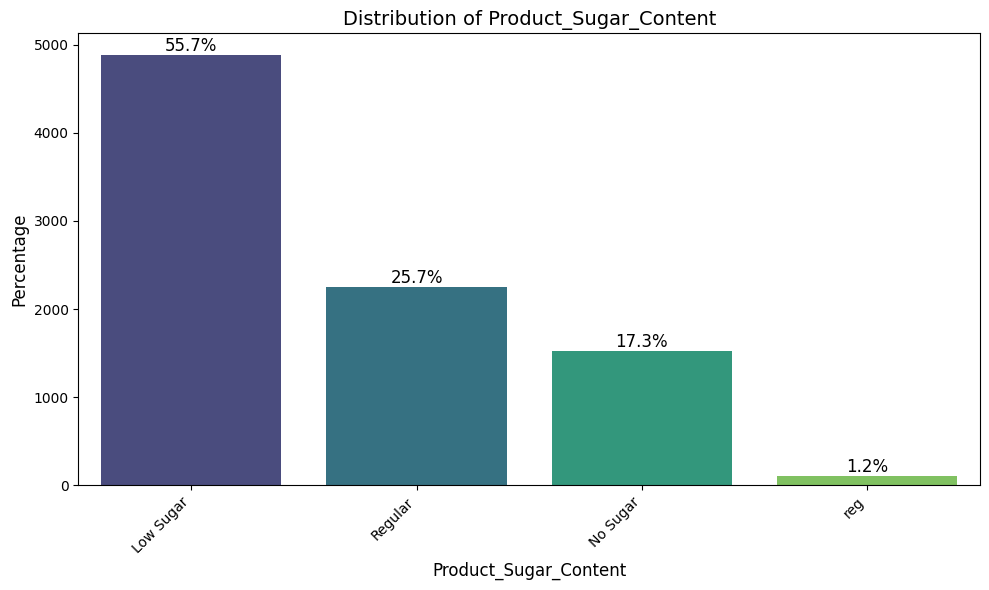

In [107]:
# Univariate analysis for 'Product_Sugar_Content' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Product_Sugar_Content', perc=True)

### Univariate Analysis of `Product_Sugar_Content` in `batchkart` DataFrame

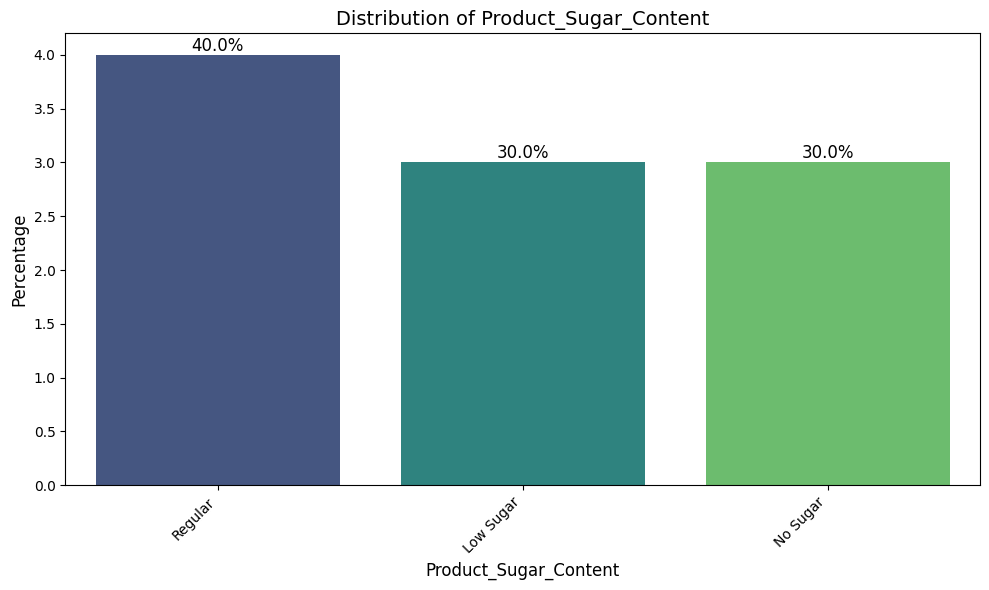

In [108]:
# Univariate analysis for 'Product_Sugar_Content' in `batchkart` DataFrame (Batch_Data_SuperKart.csv)
labeled_barplot(batchkart, 'Product_Sugar_Content', perc=True)

### Univariate Analysis of `Product_Type` in `data` DataFrame

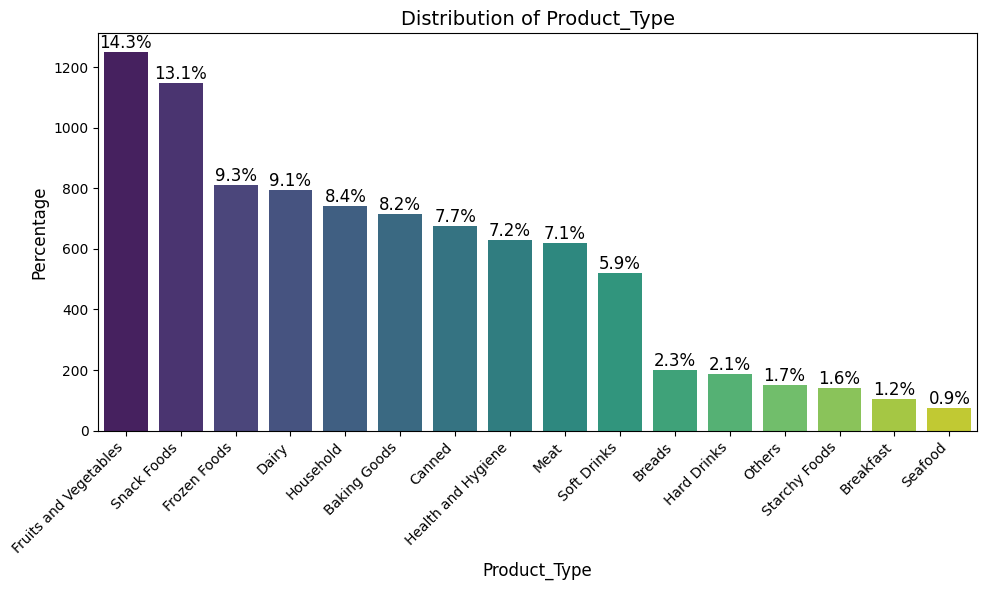

In [109]:
# Univariate analysis for 'Product_Type' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Product_Type', perc=True)

### Univariate Analysis of `Product_Type_Category` in `batchkart` DataFrame

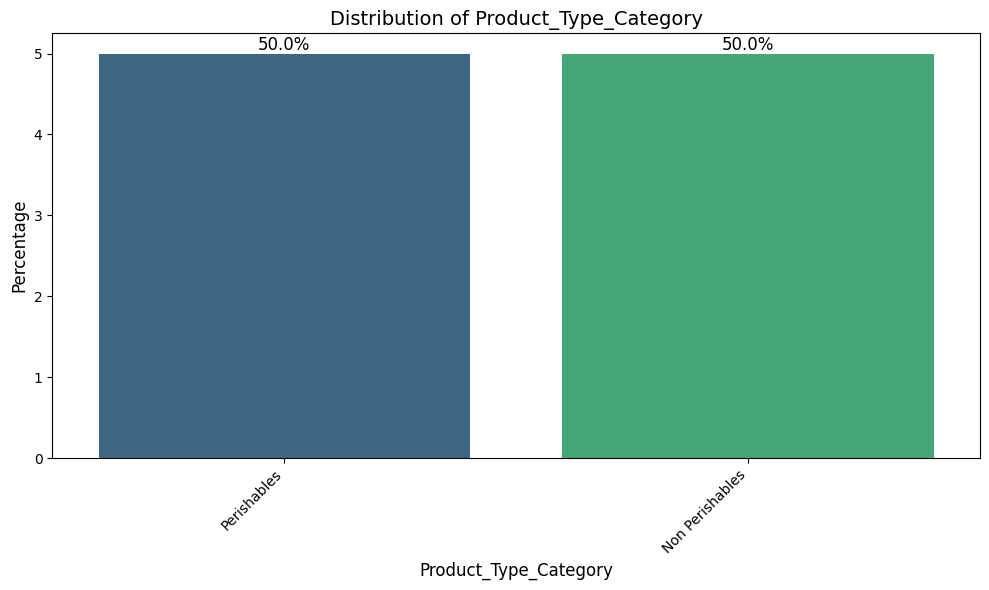

In [110]:
# Univariate analysis for 'Product_Type_Category' in `batchkart` DataFrame (Batch_Data_SuperKart.csv)
labeled_barplot(batchkart, 'Product_Type_Category', perc=True)

### Univariate Analysis of `Store_Id` in `data` DataFrame

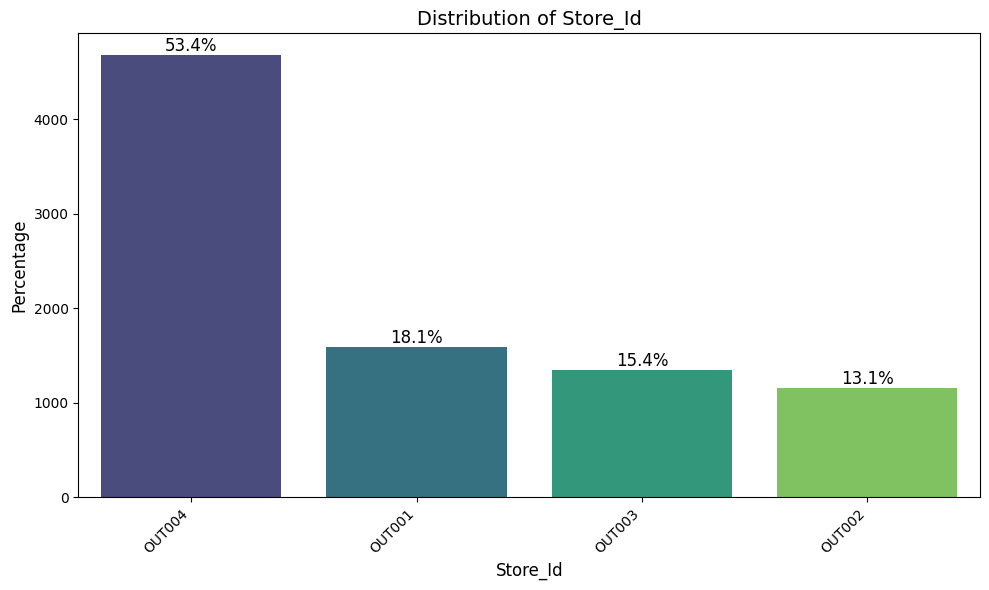

In [111]:
# Univariate analysis for 'Store_Id' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Store_Id', perc=True)

### Univariate Analysis of `Store_Size` in `data` DataFrame

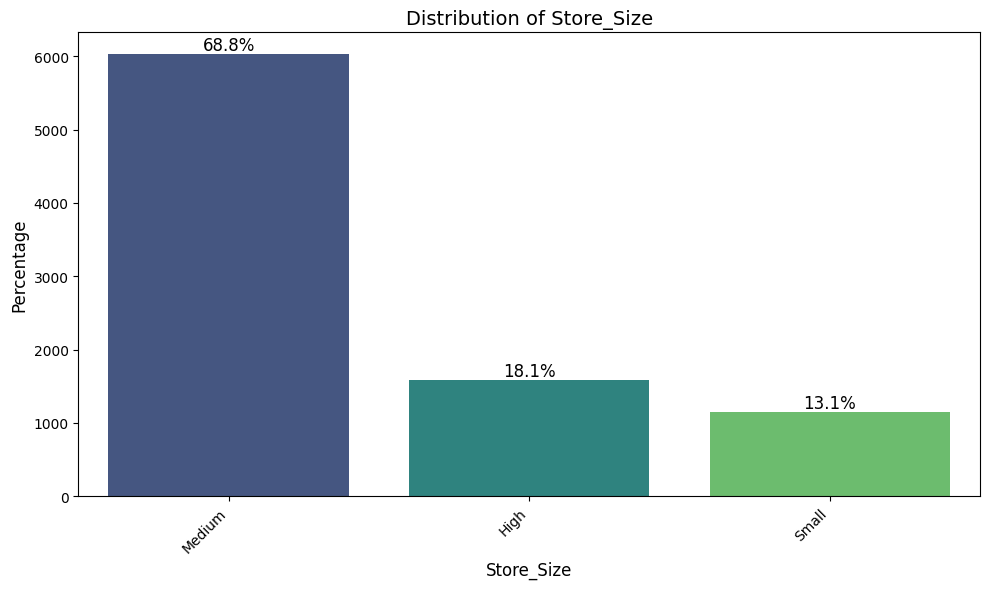

In [112]:
# Univariate analysis for 'Store_Size' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Store_Size', perc=True)

### Univariate Analysis of `Store_Size` in `batchkart` DataFrame

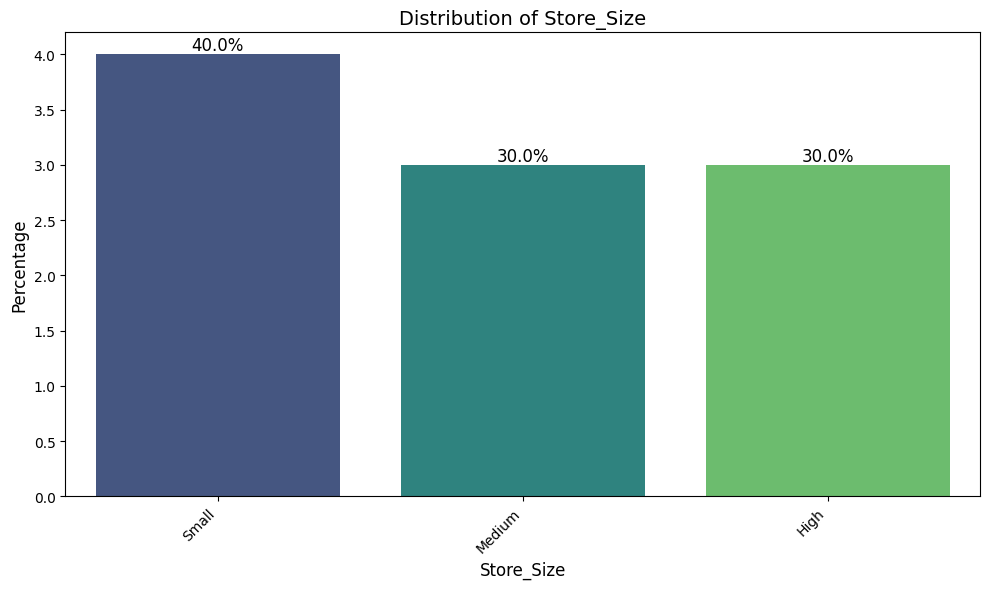

In [113]:
# Univariate analysis for 'Store_Size' in `batchkart` DataFrame (Batch_Data_SuperKart.csv)
labeled_barplot(batchkart, 'Store_Size', perc=True)

### Univariate Analysis of `Store_Location_City_Type` in `data` DataFrame

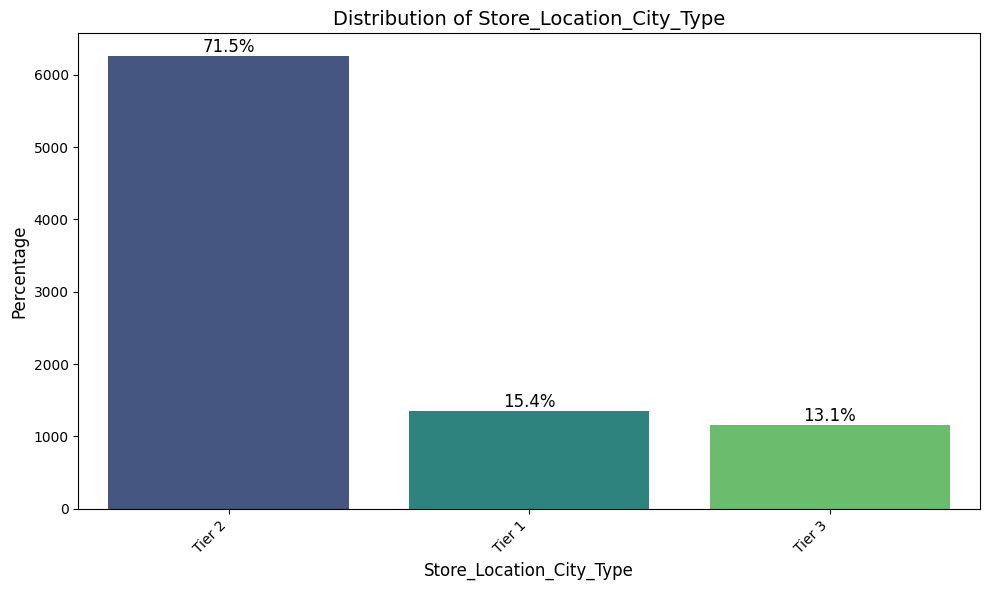

In [114]:
# Univariate analysis for 'Store_Location_City_Type' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Store_Location_City_Type', perc=True)

### Univariate Analysis of `Store_Location_City_Type` in `batchkart` DataFrame

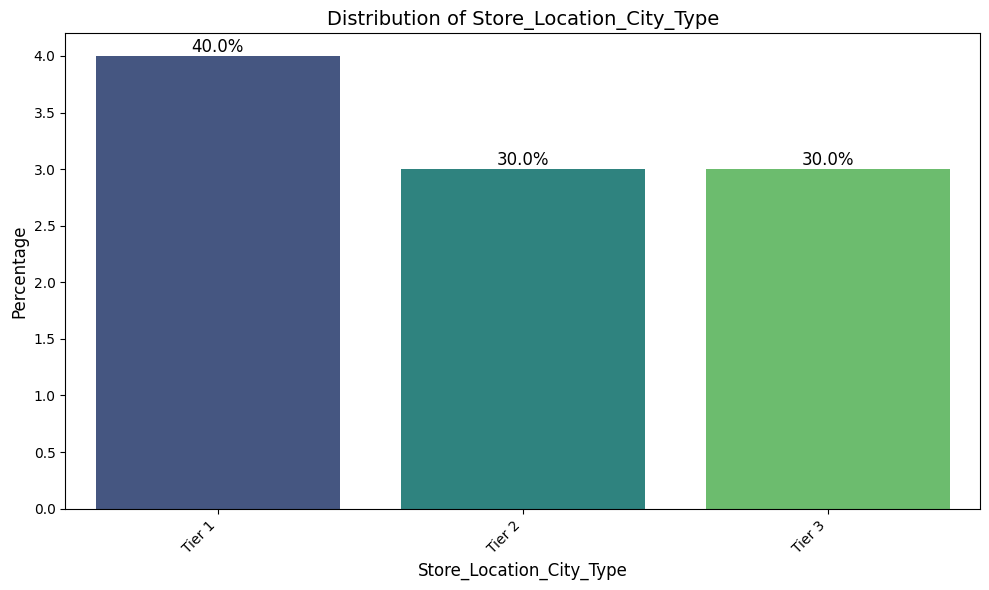

In [115]:
# Univariate analysis for 'Store_Location_City_Type' in `batchkart` DataFrame (Batch_Data_SuperKart.csv)
labeled_barplot(batchkart, 'Store_Location_City_Type', perc=True)

### Univariate Analysis of `Store_Type` in `data` DataFrame

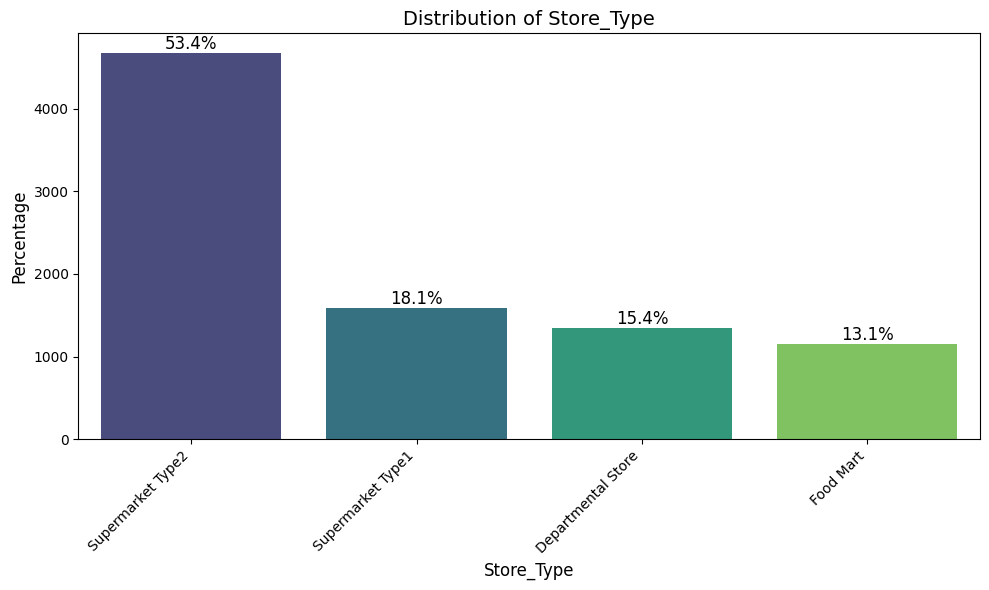

In [116]:
# Univariate analysis for 'Store_Type' in `data` DataFrame (SuperKart.csv)
labeled_barplot(data, 'Store_Type', perc=True)

### Univariate Analysis of `Store_Type` in `batchkart` DataFrame

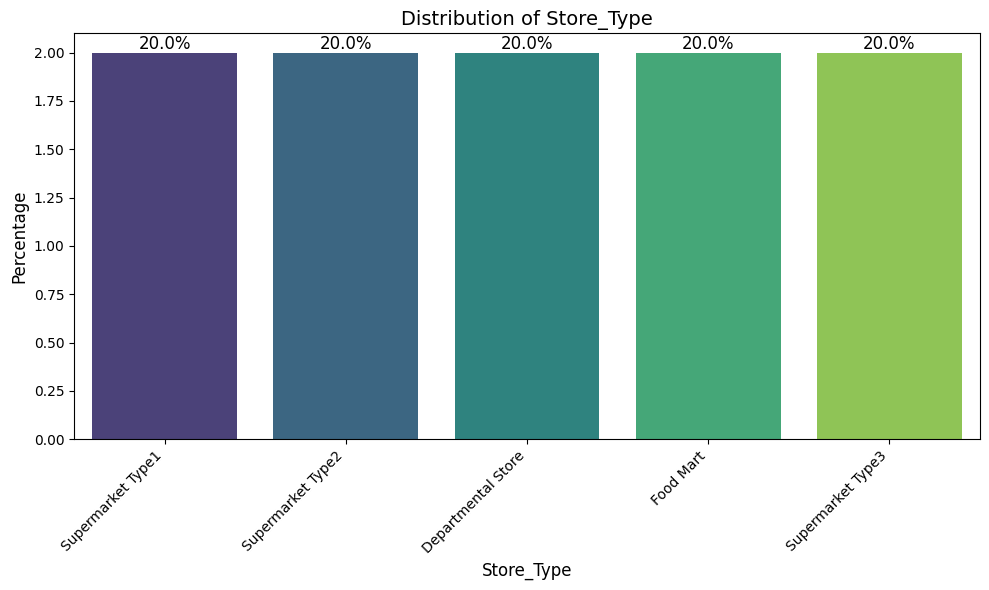

In [117]:
# Univariate analysis for 'Store_Type' in `batchkart` DataFrame (Batch_Data_SuperKart.csv)
labeled_barplot(batchkart, 'Store_Type', perc=True)

Let's perform univariate analysis for `data` `batchkart` DataFrame as well, starting with `Product_Weight`.

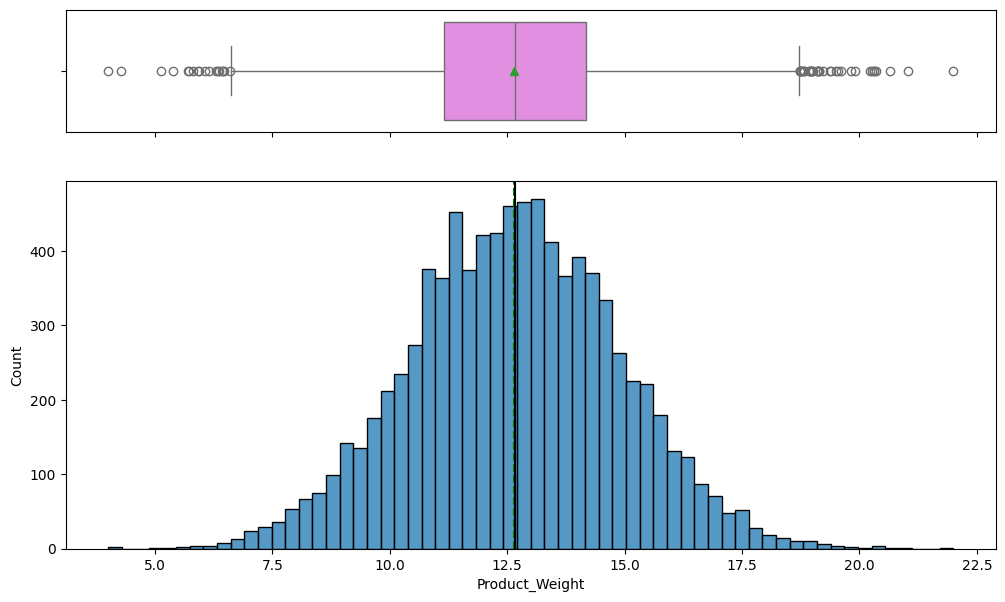

In [118]:
# Univariate analysis for `Product_Weight` in `data` DataFrame (from `SuperKart.csv`)
histogram_boxplot(data, "Product_Weight")

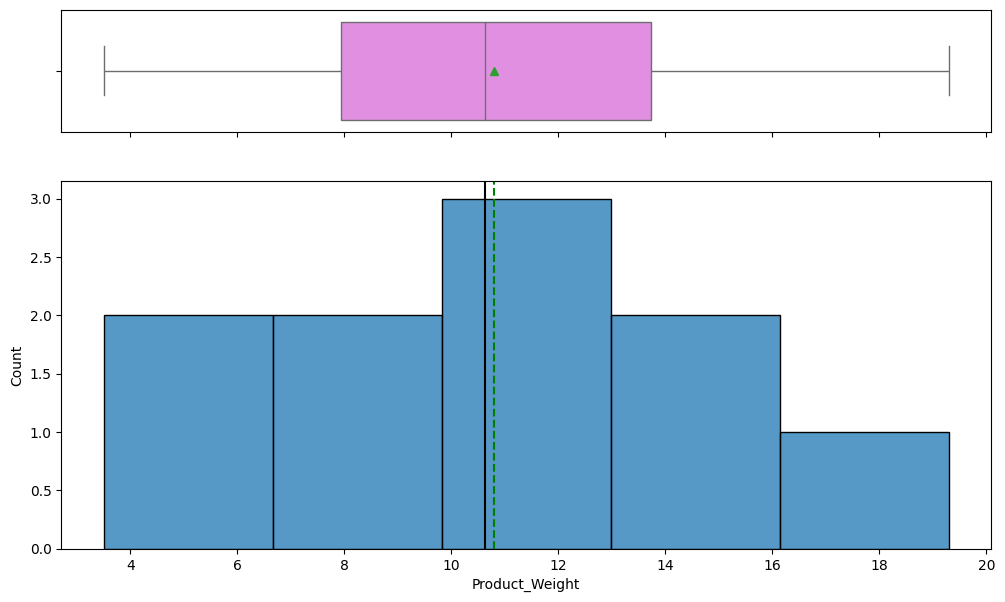

In [119]:
# Univariate analysis for `Product_Weight` in `batchkart` DataFrame (from `Batch_Data_SuperKart.csv`)
histogram_boxplot(batchkart, "Product_Weight")

Let's analyze `Product_Allocated_Area` for both the `data` DataFrame (from `SuperKart.csv`) and the `batchkart` DataFrame (from `Batch_Data_SuperKart.csv`).

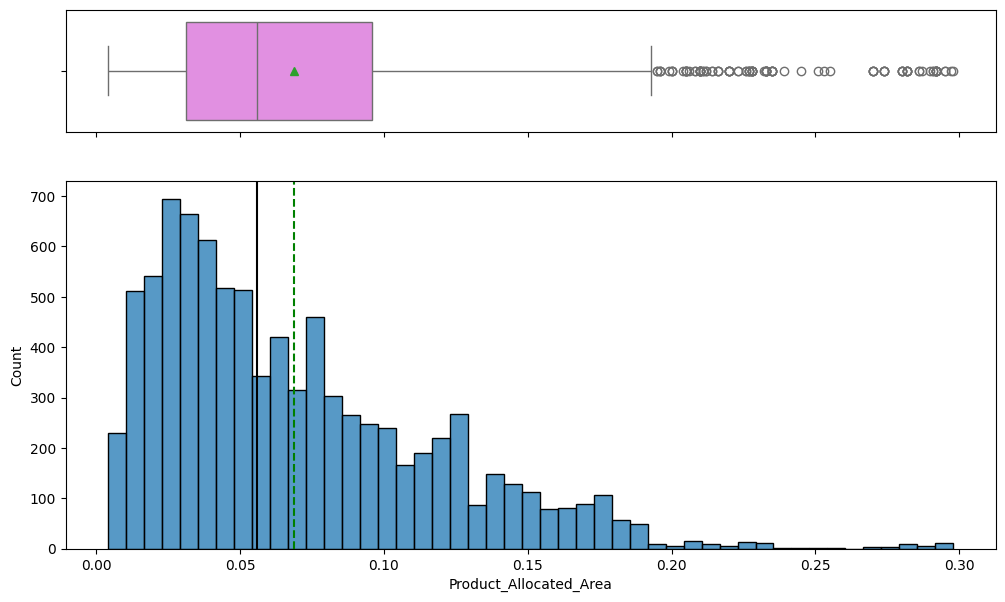

In [120]:
# Univariate analysis for `Product_Allocated_Area` in `data` DataFrame (from `SuperKart.csv`)
histogram_boxplot(data, "Product_Allocated_Area")

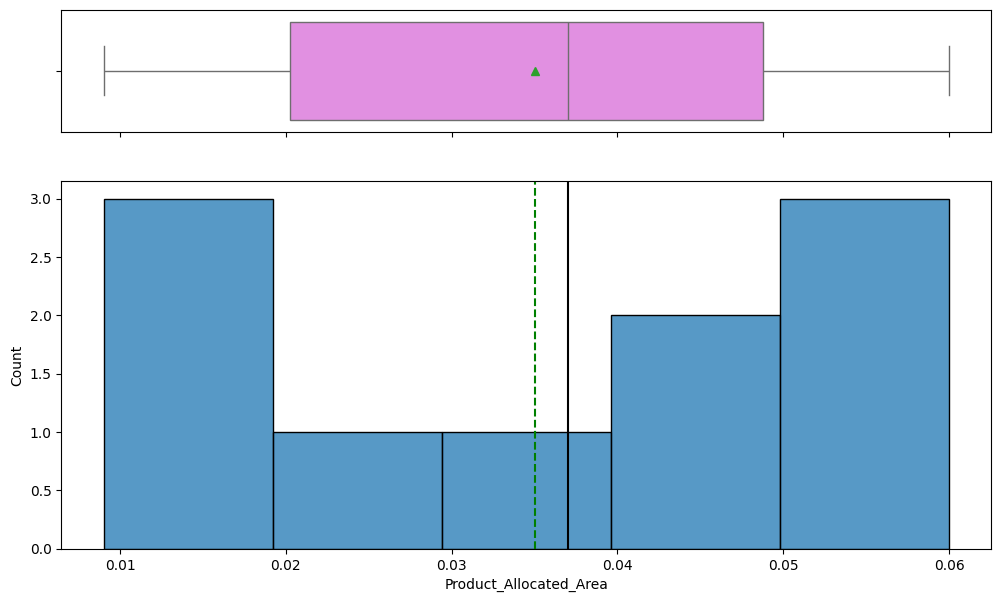

In [121]:
# Univariate analysis for `Product_Allocated_Area` in `batchkart` DataFrame (from `Batch_Data_SuperKart.csv`)
histogram_boxplot(batchkart, "Product_Allocated_Area")

Finally, let's analyze `Product_MRP` for both the `data` DataFrame (from `SuperKart.csv`) and the `batchkart` DataFrame (from `Batch_Data_SuperKart.csv`).

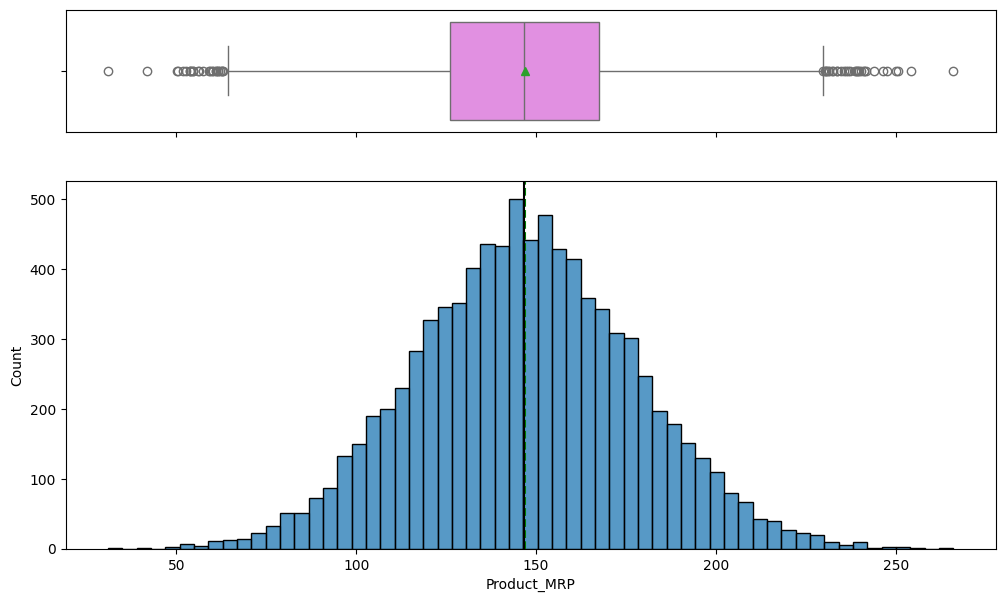

In [122]:
# Univariate analysis for `Product_MRP` in `data` DataFrame (from `SuperKart.csv`)
histogram_boxplot(data, "Product_MRP")

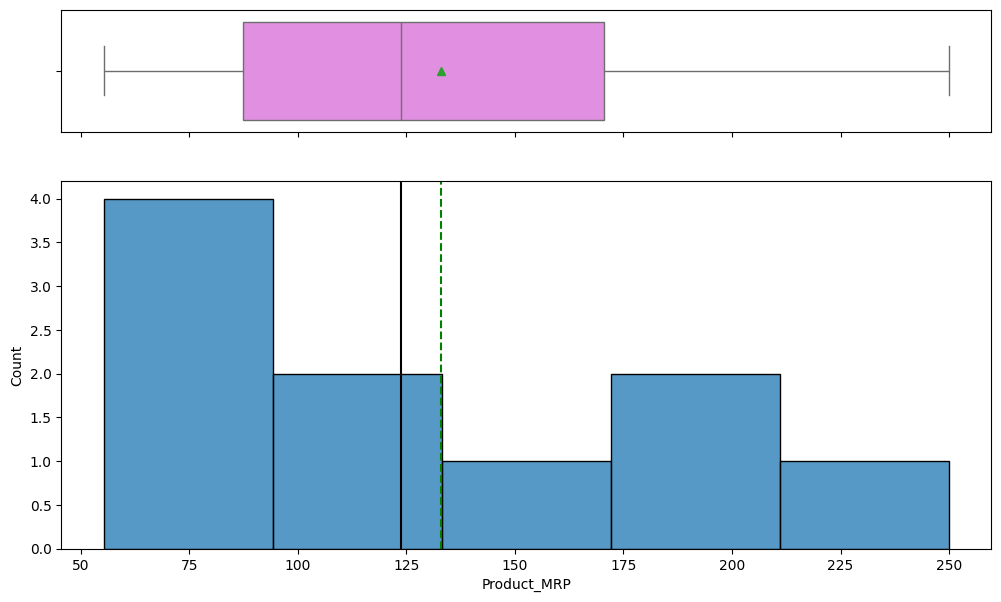

In [123]:
# Univariate analysis for `Product_MRP` in `batchkart` DataFrame (from `Batch_Data_SuperKart.csv`)
histogram_boxplot(batchkart, "Product_MRP")

Finally, let's analyze `Product_Store_Sales_Total` for the `data` DataFrame (from `SuperKart.csv`). This column is not present in `batchkart`.

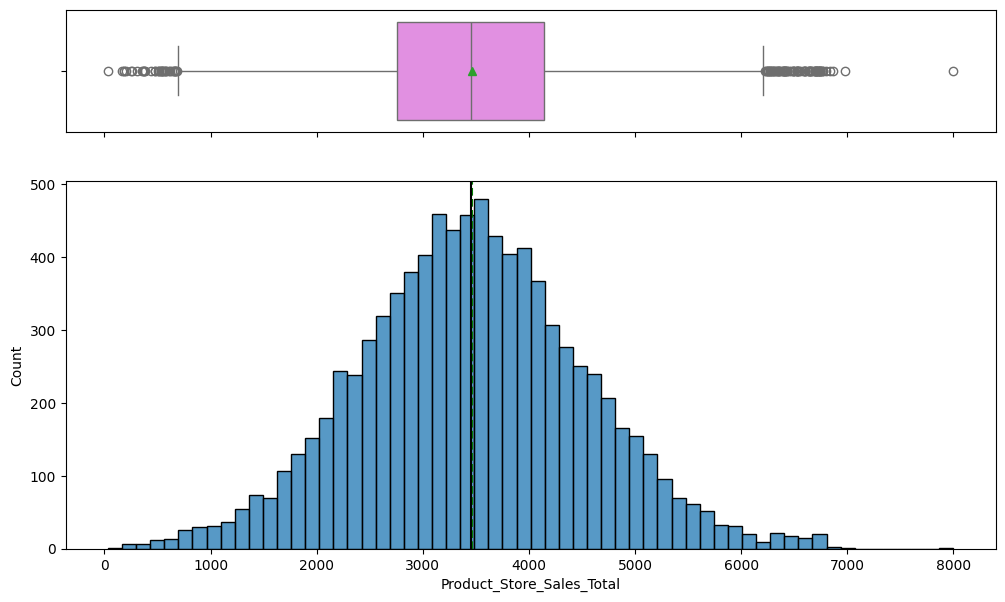

In [124]:
# Univariate analysis for `Product_Store_Sales_Total` in `data` DataFrame (from `SuperKart.csv`)
histogram_boxplot(data, "Product_Store_Sales_Total")

## Bivariate Analysis

### Correlation Matrix for `data` DataFrame

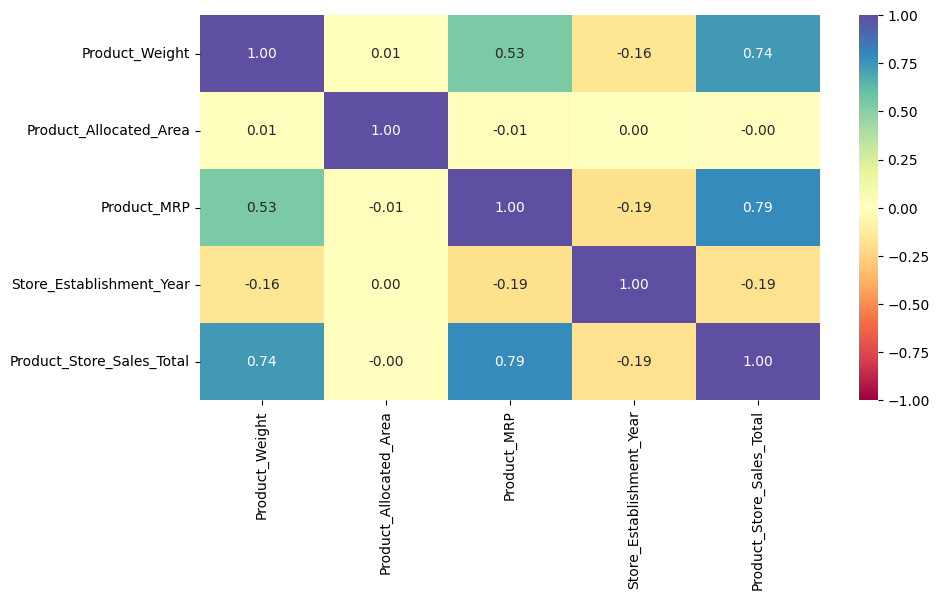

In [125]:
# Correlation Matrix
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

### Correlation Matrix for `batchkart` DataFrame

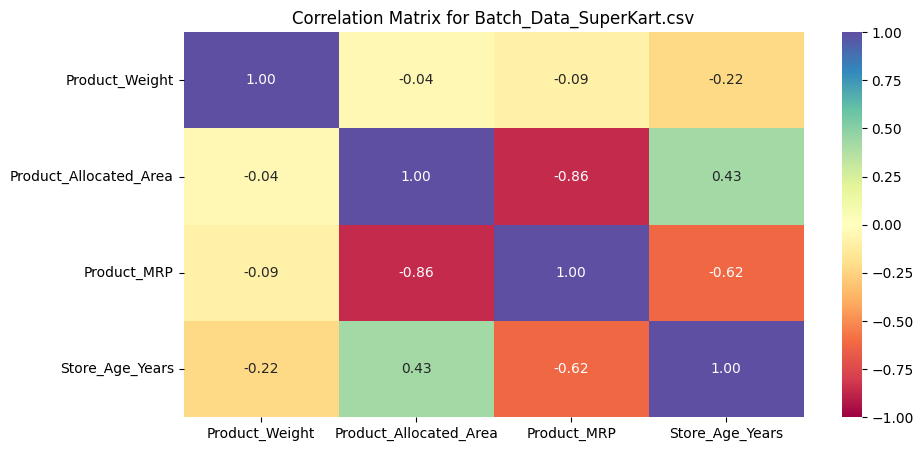

In [126]:
# Correlation Matrix for `batchkart` DataFrame
batch_cols_list = batchkart.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    batchkart[batch_cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title('Correlation Matrix for Batch_Data_SuperKart.csv')
plt.show()

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns 'SuperKart.csv.'**

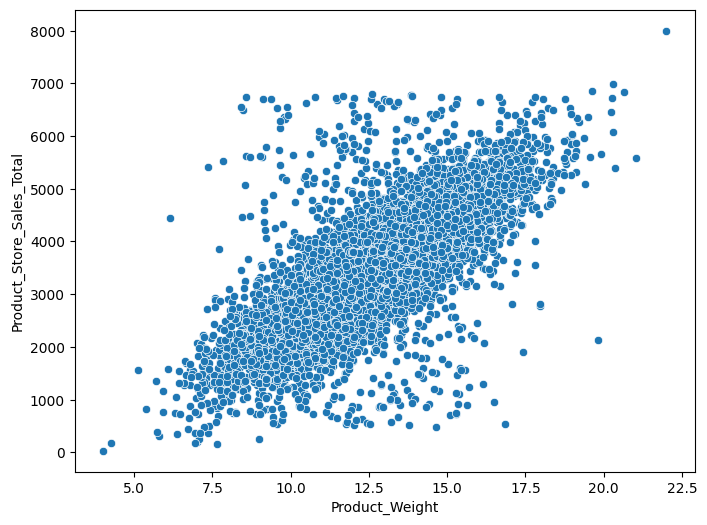

In [127]:
#Code to plot a scatterplot of Product_Weight and Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

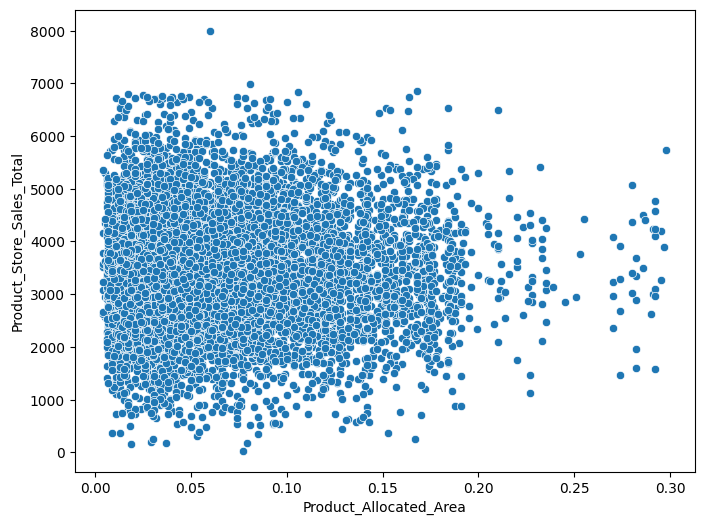

In [128]:
#Code to plot a scatterplot of Product_Allocated_Area and Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Allocated_Area, y=data.Product_Store_Sales_Total)
plt.show()

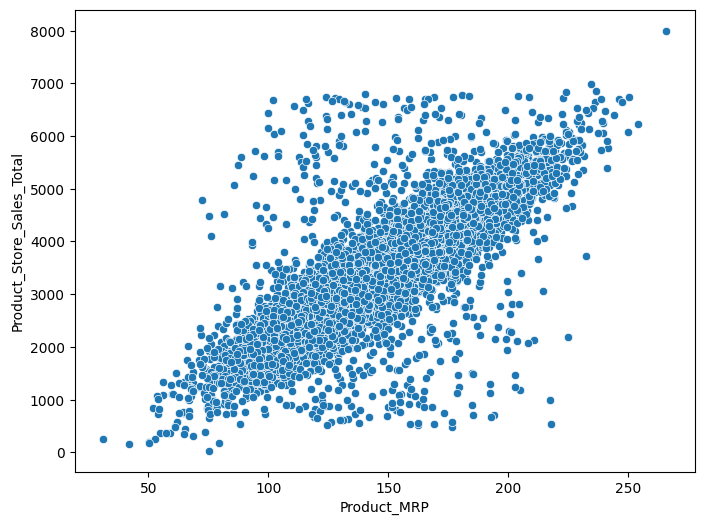

In [129]:
#Code to plot a scatterplot of Product_MRP and Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_MRP, y=data.Product_Store_Sales_Total)
plt.show()

### **Let us see from which product type the company is generating most of the revenue `SuperKart.csv.`**

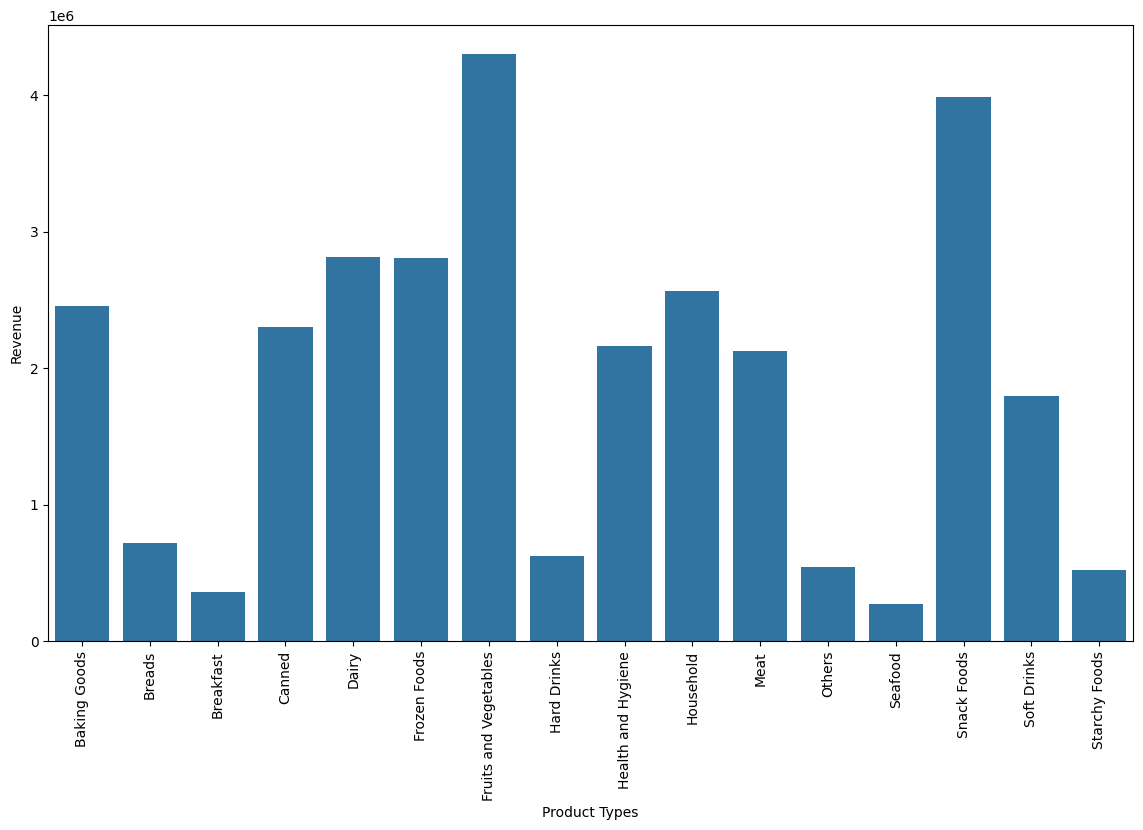

In [130]:
 #Code to perform a groupby on Product_Type and select Product_Store_Sales_Total
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

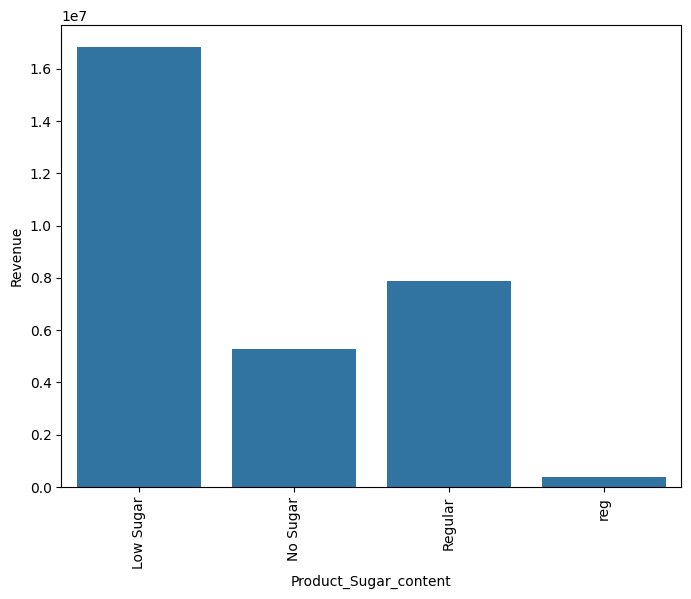

In [131]:

 #Code to perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()  #Complete the code to perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

### **Let us see from which type of stores and locations the revenue generation is more**.

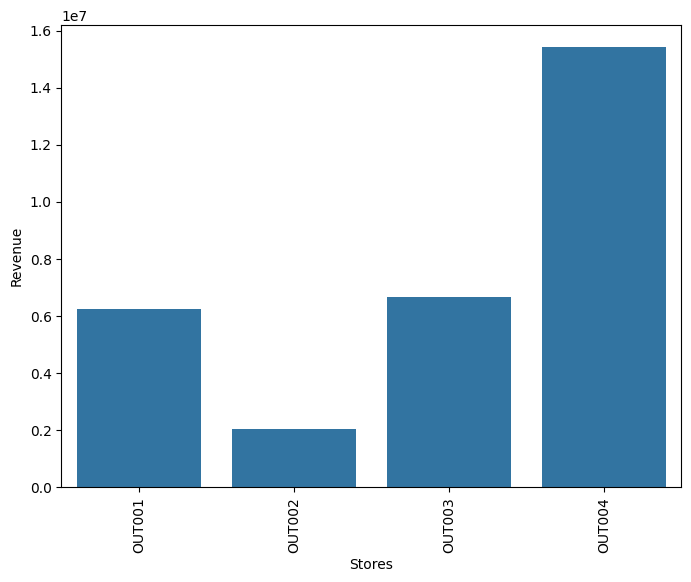

In [132]:
#Complete the code to perform a groupby on Store_Id and select Product_Store_Sales_Total
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

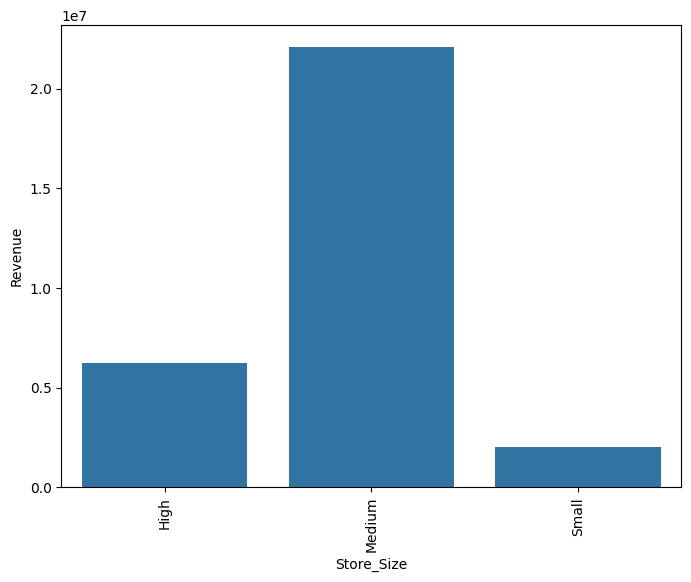

In [133]:
 #Code to perform a groupby on Store_Size and select Product_Store_Sales_Total
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

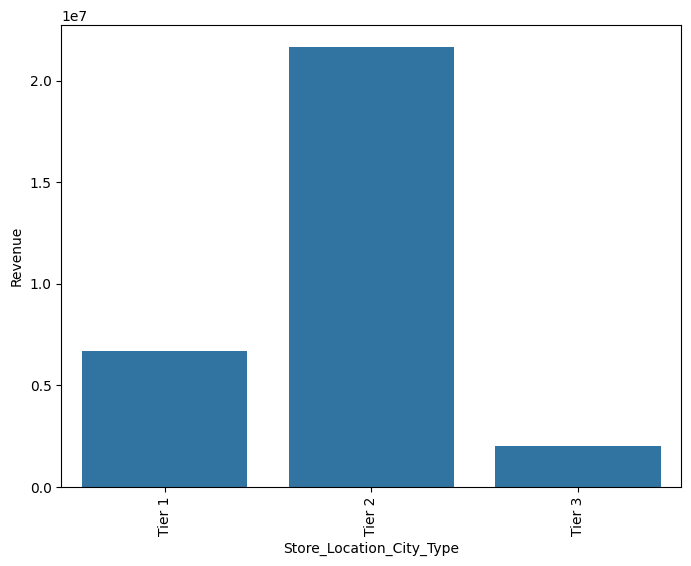

In [134]:
#Code to perform a groupby on Store_Location_City_Type and select Product_Store_Sales_Total
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

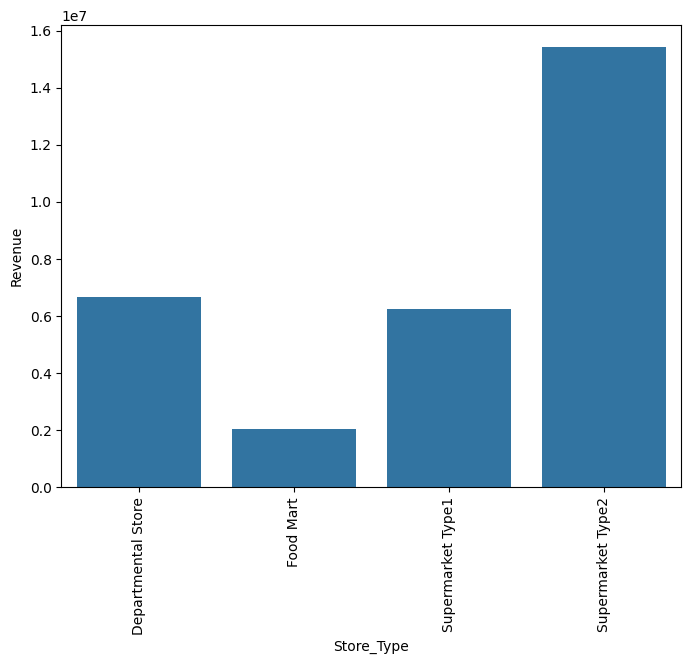

In [135]:
#Code to perform a groupby on Store_Type and select Product_Store_Sales_Total
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

### **Let us see from which type of stores and locations the revenue generation is more**.

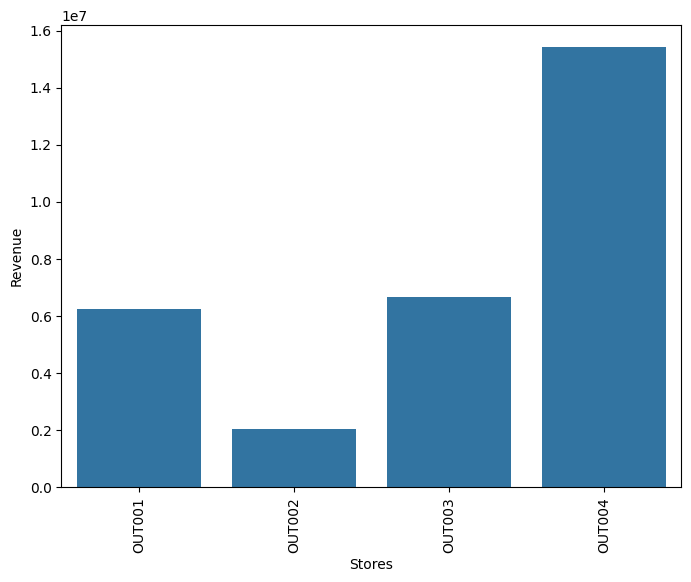

In [136]:
#Code to perform a groupby on Store_Id and select Product_Store_Sales_Total
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

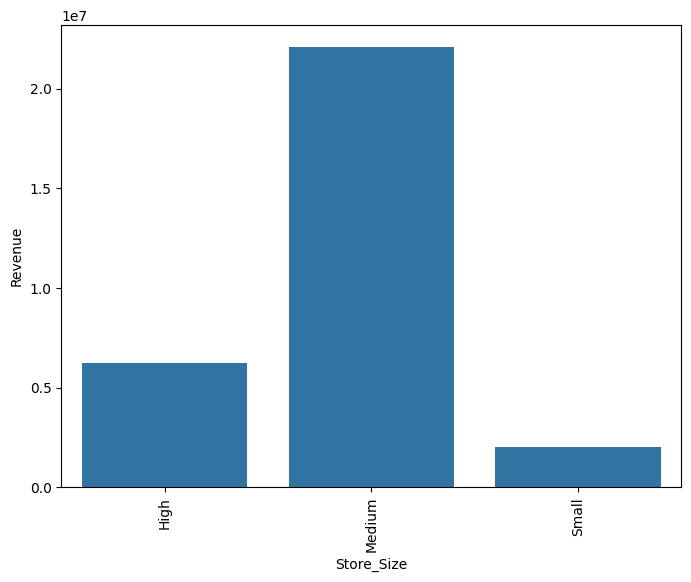

In [137]:

#Code to perform a groupby on Store_Size and select Product_Store_Sales_Total
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

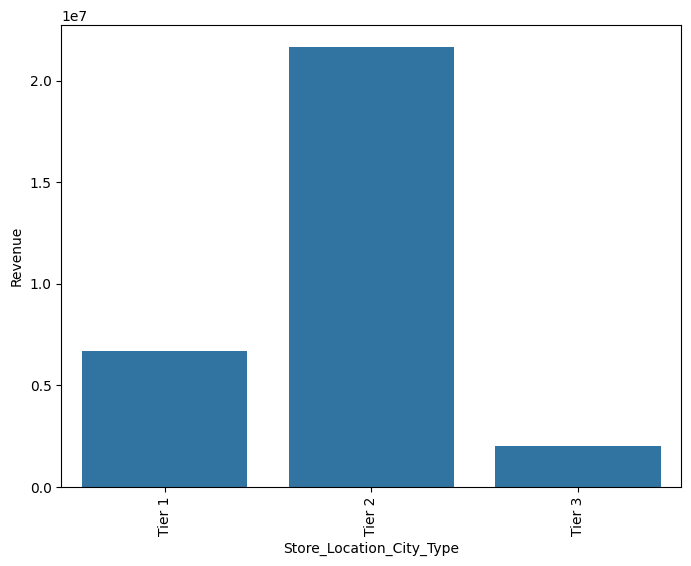

In [138]:
#Code to perform a groupby on Store_Location_City_Type and select Product_Store_Sales_Total
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

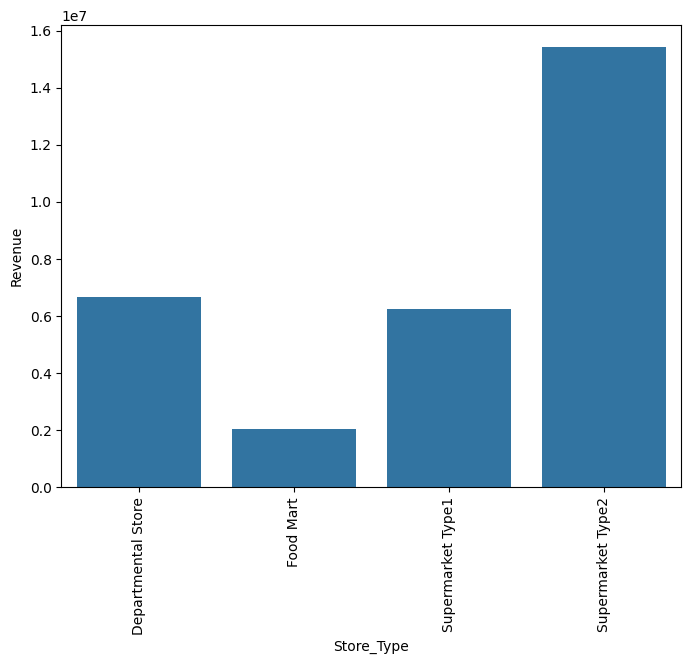

In [139]:
 #Code to perform a groupby on Store_Type and select Product_Store_Sales_Total
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

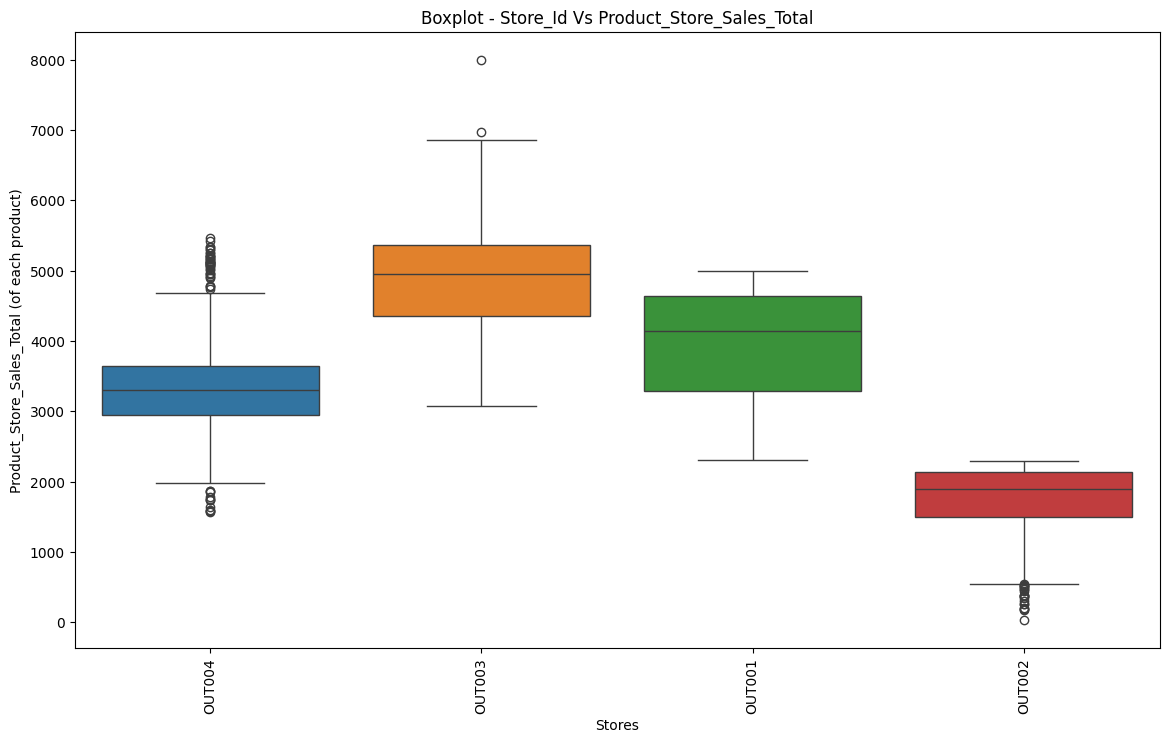

In [140]:
#Code to plot the boxplot with x as Store_id , y as Product_Store_Sales_Total and hue as Store_Id
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

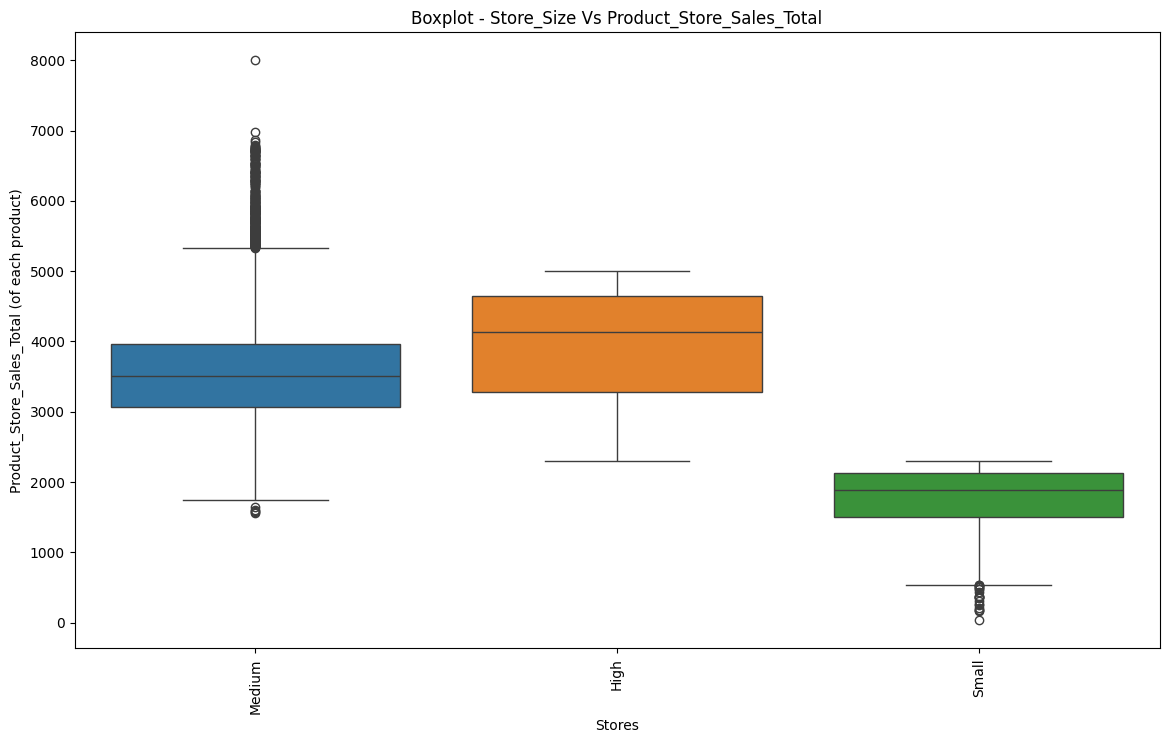

In [141]:
#Complet the code to plot the boxplot with x as Store_Size , y as Product_Store_Sales_Total and hue as Store_Size
# This boxplot visualizes the distribution of `Product_Store_Sales_Totalt` for each `Store_Size` category in the `SuperKart.csv` dataset.
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

### **Let's now try to find out some relationship between the other columns**

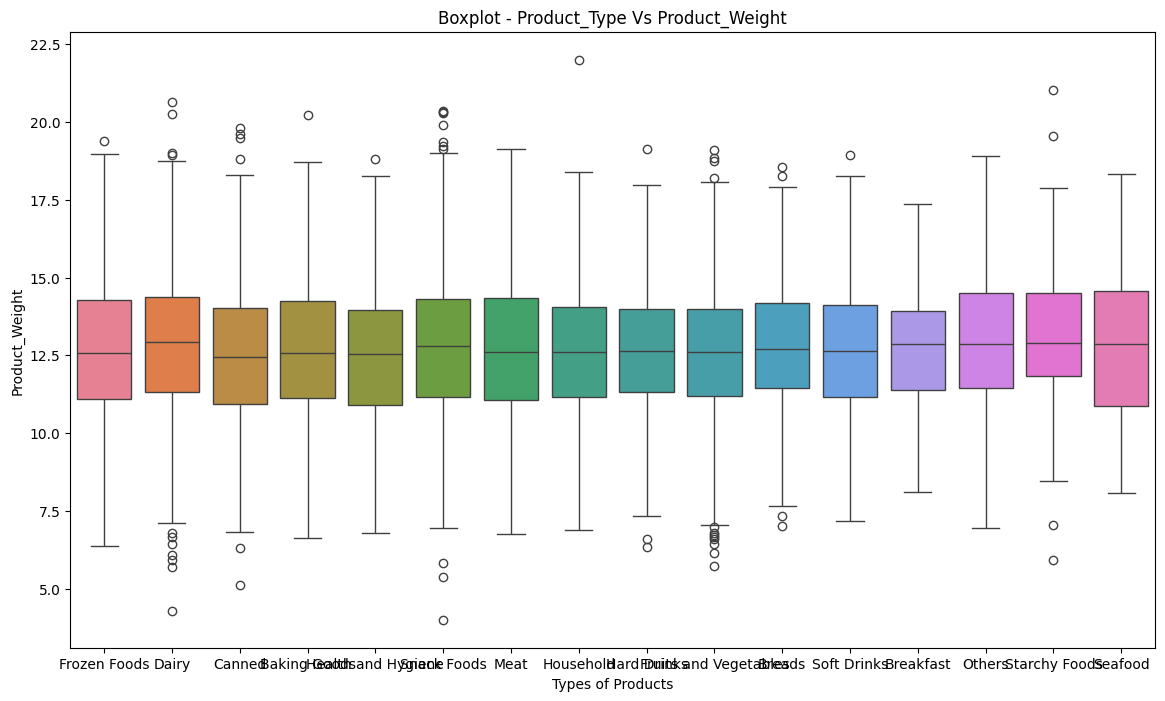

In [142]:
# Code to plot the boxplot with x as Product_Type , y as Product_Weight and hue as Product_Type for `SuperKart.csv`
# This boxplot visualizes the distribution of `Product_Weight` for each `Product_Type` category in the `SuperKart.csv` dataset.
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type")
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

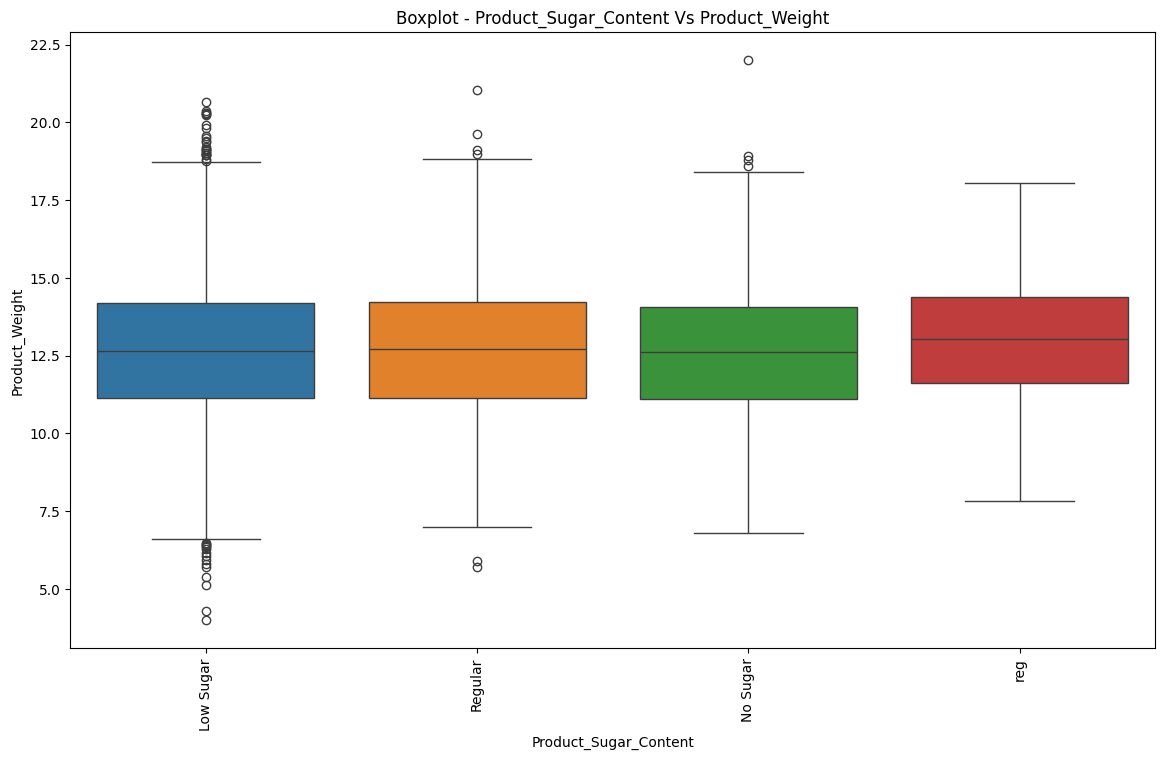

In [143]:
#Code to plot the boxplot with x as Product_Sugar_Content , y as Product_Weight and hue as Product_Sugar_Content
# This boxplot visualizes the distribution of `Product_Weight` for each `Product_Sugar_Content` category in the `SuperKart.csv` dataset.
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

### **Let's analyze the sugar content of different product types**

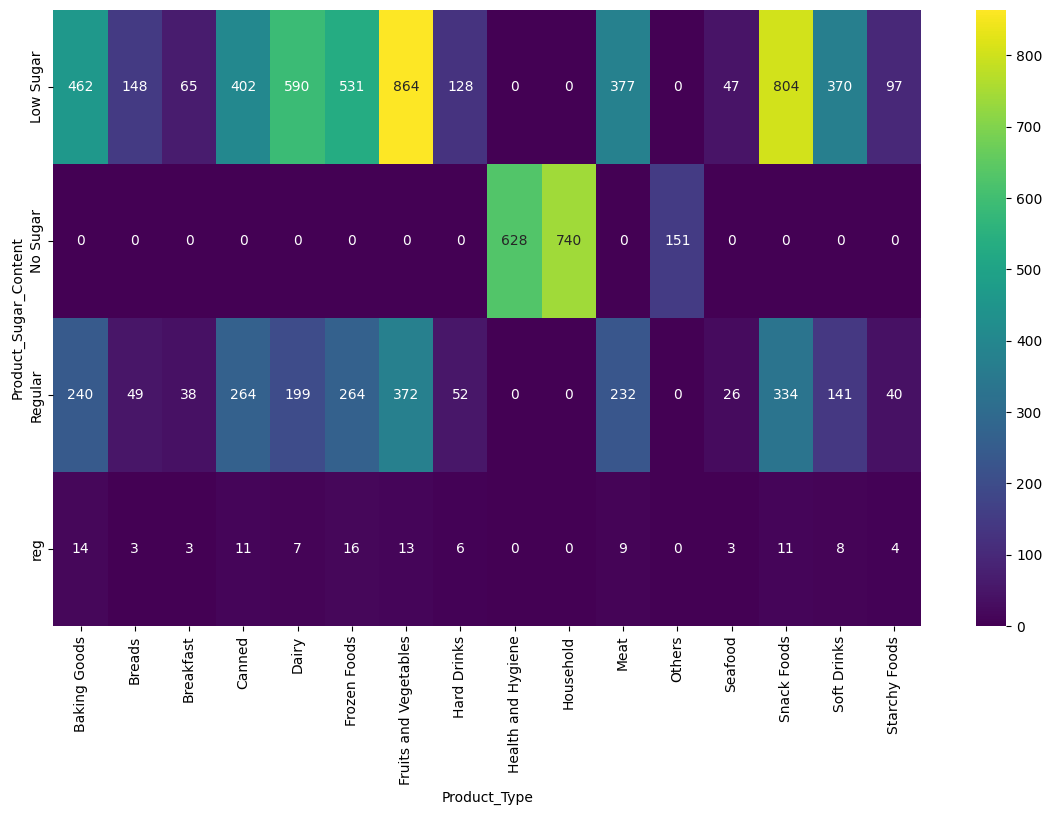

In [144]:
# This heatmap visualizes the distribution of `Product_Sugar_Content` across different `Product_Type` categories for the `SuperKart.csv` dataset, showing the frequency of each combination.
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

### **Let's find out how many items of each product type has been sold in each of the stores**

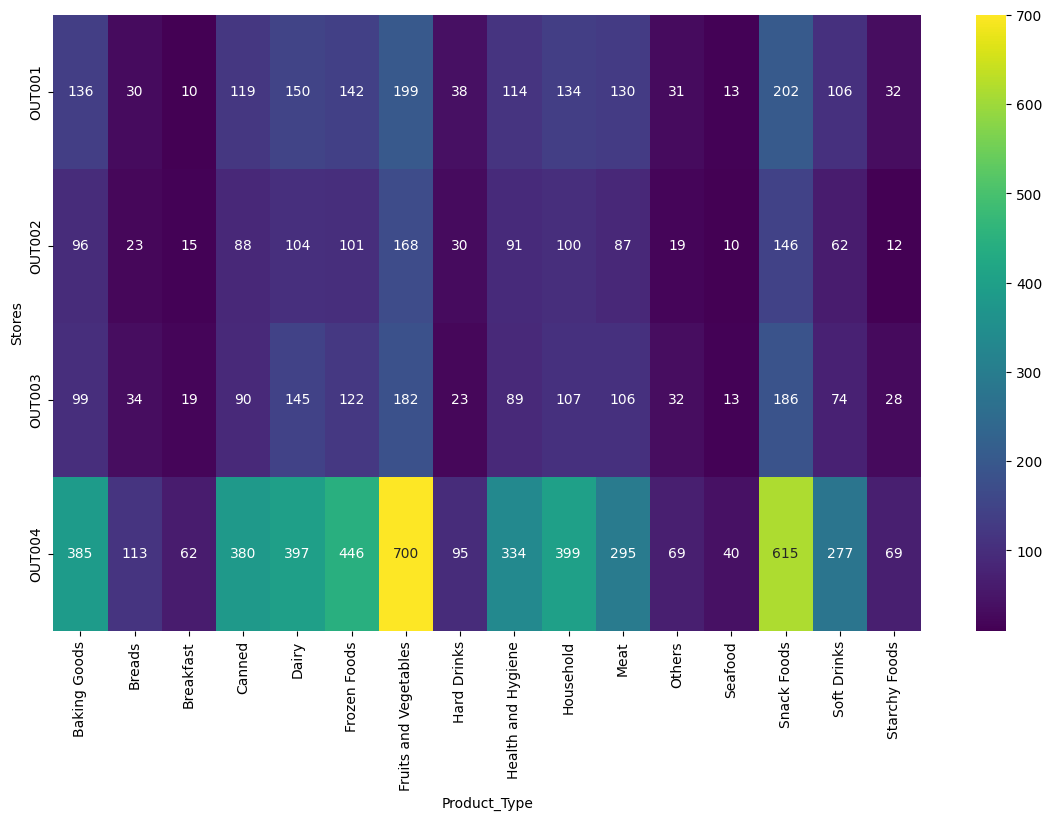

In [145]:
#Code to perform a crosstab operation between Store_Id and Product_Type
# This heatmap visualizes the distribution of `Store_Id` across different `Product_Type` categories for the `SuperKart.csv` dataset, showing the frequency of each combination.
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

### **Different product types have different prices. Let's analyze the trend.**

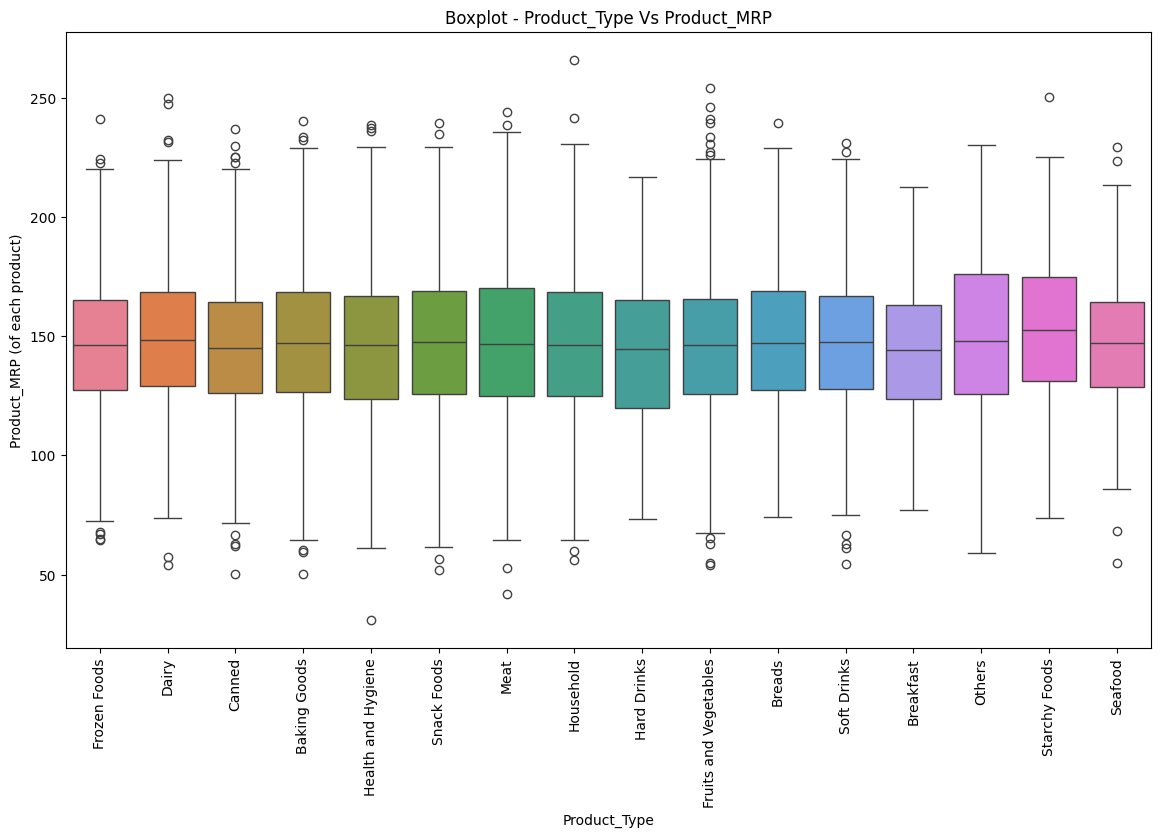

In [146]:
 #Code to plot a boxplot with x as Product_Type , y as Product_MRP and hue as Product_Type
 # This boxplot visualizes the distribution of `Product_MRP` for each `Product_Type` category in the `SuperKart.csv` dataset.
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's find out how the Product_MRP varies with the different stores**

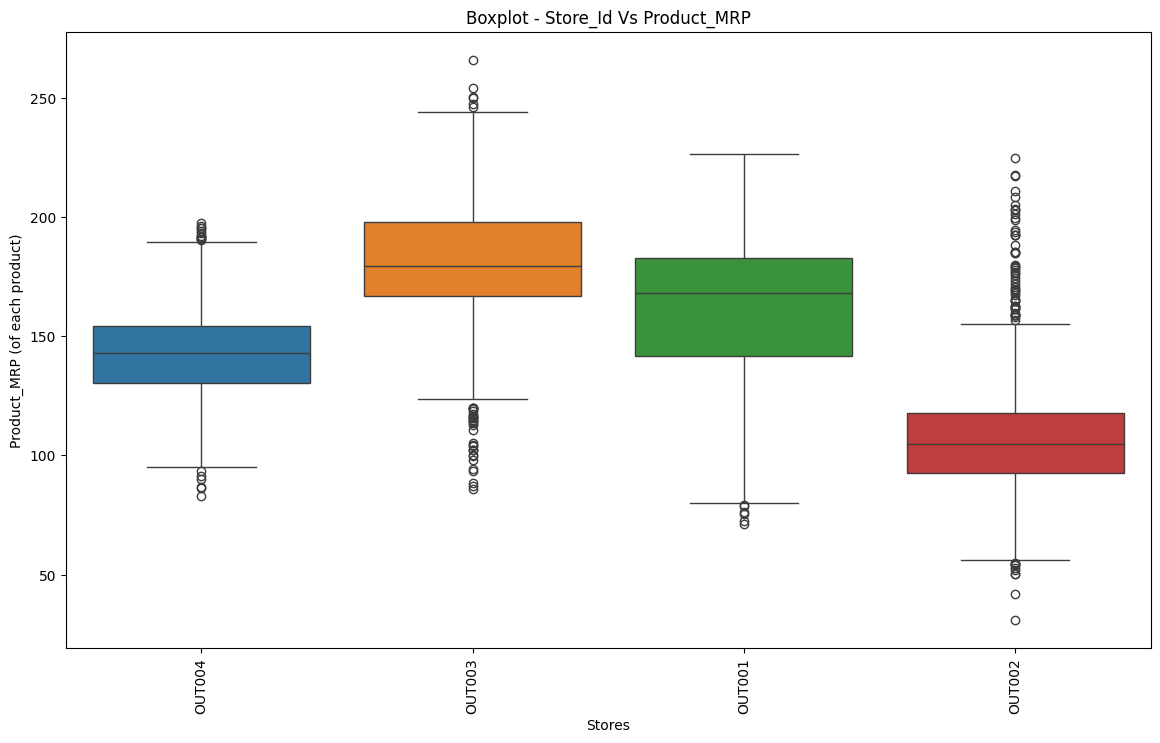

In [147]:
#Code to plot the boxplot with x as Store_Id , y as Product_MRP and hue as Store_Id
# This boxplot visualizes the distribution of `Product_MRP` for each `Store_Id` category in the `SuperKart.csv` dataset.
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001



In [148]:
# This code provides a comprehensive statistical summary of the `SuperKart.csv` dataset filtered specifically for `Store_Id` 'OUT001', offering insights into its product characteristics and sales performance.
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,NC7187,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high. It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.

In [149]:
# This code calculates the total `Product_Store_Sales_Total` for `Store_Id` 'OUT001' from the `SuperKart.csv` dataset, providing the overall revenue generated by this specific store.
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**OUT001 has generated total revenue of 6223113 from the sales of goods.**

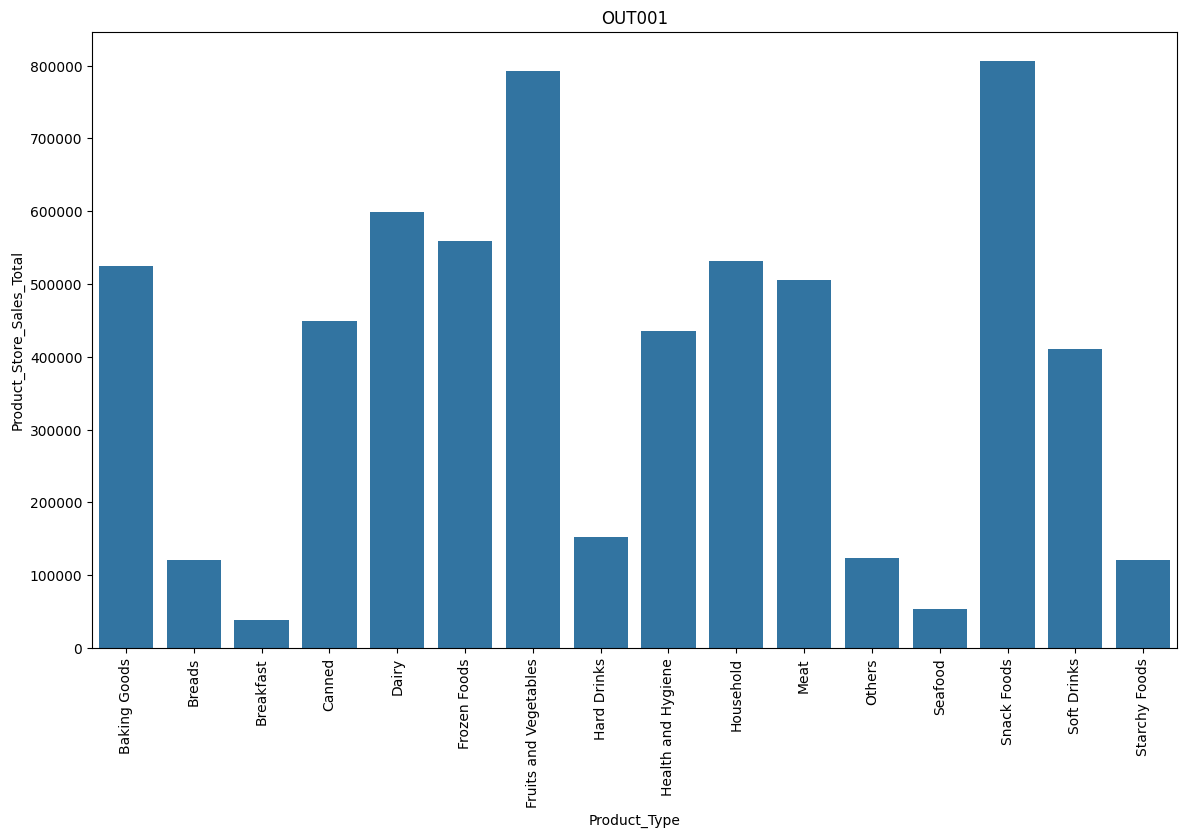

In [150]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` for `Store_Id` 'OUT001' and calculates the total `Product_Store_Sales_Total` for each product type, then visualizes the results in a bar plot to show revenue distribution by product type for this specific store.
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### OUT002

In [151]:
# This code provides a comprehensive statistical summary of the `SuperKart.csv` dataset filtered specifically for `Store_Id` 'OUT002', offering insights into its product characteristics and sales performance.
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,FD2446,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.

In [153]:
# This code calculates the total `Product_Store_Sales_Total` for `Store_Id` 'OUT002' from the `SuperKart.csv` dataset, providing the overall revenue generated by this specific store.
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

**OUT002 has generated total revenue of 2030910 from the sales of goods.**

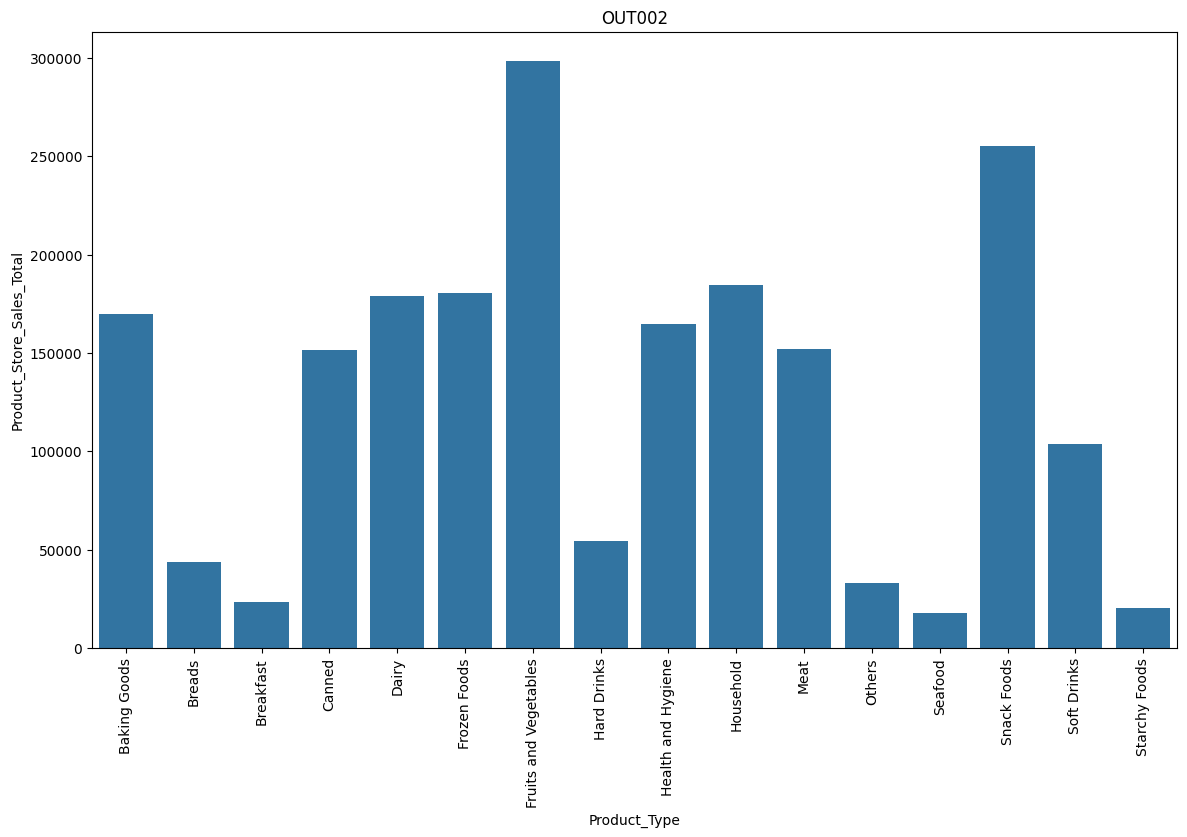

In [152]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` for `Store_Id` 'OUT002' and calculates the total `Product_Store_Sales_Total` for each product type, then visualizes the results in a bar plot to show revenue distribution by product type for this specific store.
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### OUT003

In [154]:
# This code provides a comprehensive statistical summary of the `SuperKart.csv` dataset filtered specifically for `Store_Id` 'OUT003', offering insights into its product characteristics and sales performance.
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.

In [155]:
# This code calculates the total `Product_Store_Sales_Total` for `Store_Id` 'OUT003' from the `SuperKart.csv` dataset, providing the overall revenue generated by this specific store.
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**OUT003 has generated total revenue of 6673458 from the sales of goods.**

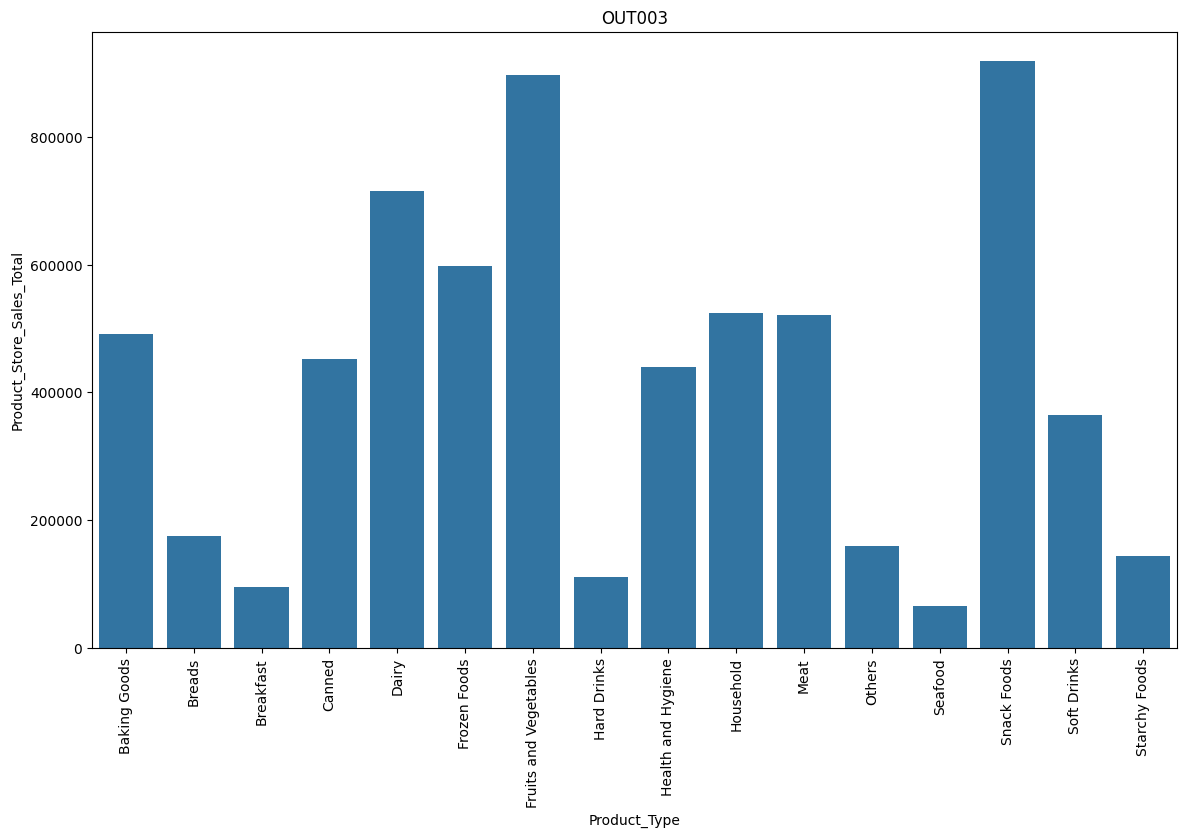

In [156]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` for `Store_Id` 'OUT003' and calculates the total `Product_Store_Sales_Total` for each product type, then visualizes the results in a bar plot to show revenue distribution by product type for this specific store.
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### OUT004

In [157]:
# This code provides a comprehensive statistical summary of the `SuperKart.csv` dataset filtered specifically for `Store_Id` 'OUT004', offering insights into its product characteristics and sales performance.
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.

In [158]:
# This code calculates the total `Product_Store_Sales_Total` for `Store_Id` 'OUT004' from the `SuperKart.csv` dataset, providing the overall revenue generated by this specific store.
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

**OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.**

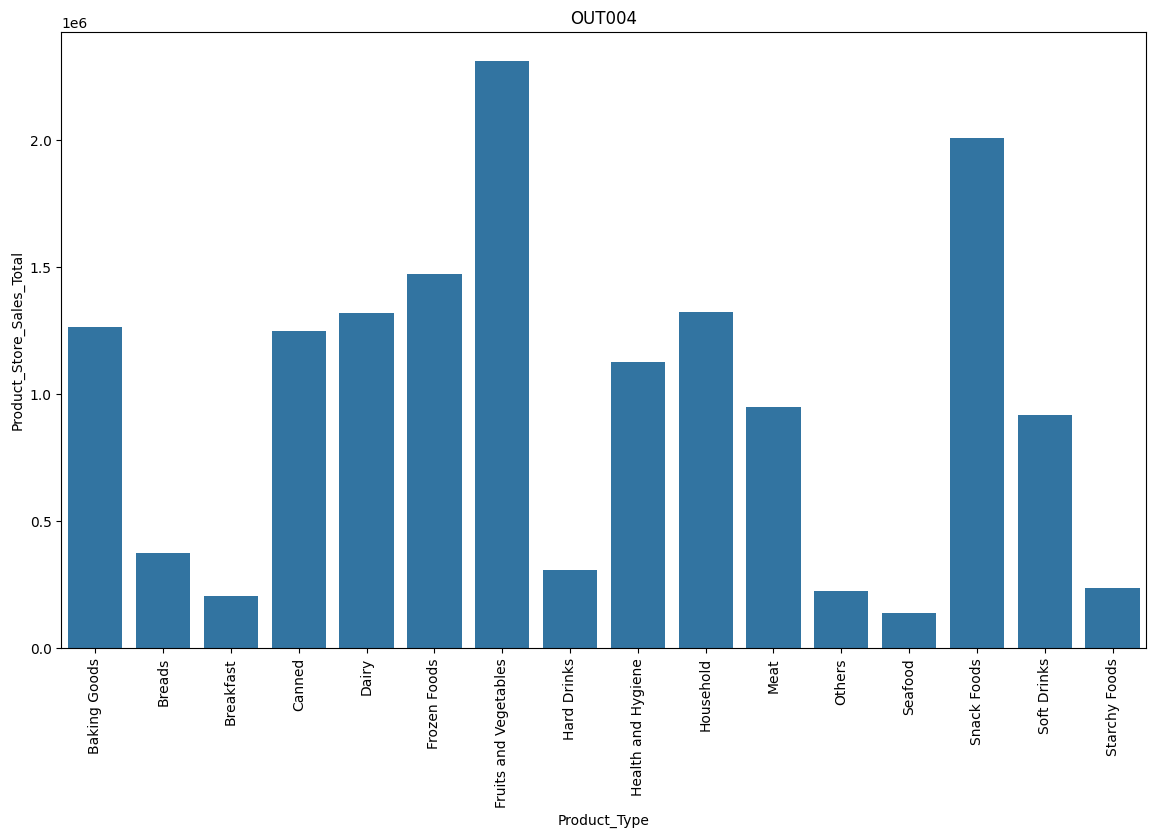

In [159]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` for `Store_Id` 'OUT004' and calculates the total `Product_Store_Sales_Total` for each product type, then visualizes the results in a bar plot to show revenue distribution by product type for this specific store.
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

- OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

**Let's find out the revenue generated by the stores from each of the product types**.

In [160]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` and `Store_Id` to calculate the total `Product_Store_Sales_Total` for each product type within each store, providing insights into store-specific product performance.
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [161]:
# This code groups the `SuperKart.csv` dataset by `Product_Type` and `Store_Id` to calculate the total `Product_Store_Sales_Total` for each product type within each store, providing insights into store-specific product performance.
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


- The trend is the same as that which was present in the revenue analysis of stores for product types.

# **Data Preprocessing**

## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [162]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [163]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [164]:
## extracting the first two characters from the Product_Id column and storing it in another column
# The code data.Product_Sugar_Content.value_counts() returns a Series containing the counts of unique values in the Product_Sugar_Content column of the data DataFrame.
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [165]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [166]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

In [167]:
data.loc[data.Product_Id_char == "_____+", "Product_Type"].unique() #Complete the code to select the rows where Product_Id_char is DR

array([], dtype=object)

In [168]:
data.loc[data.Product_Id_char == "_____", "Product_Type"].unique() #Complete the code to select the rows where Product_Id_char is NC

array([], dtype=object)

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [169]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [170]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [171]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [172]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [173]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

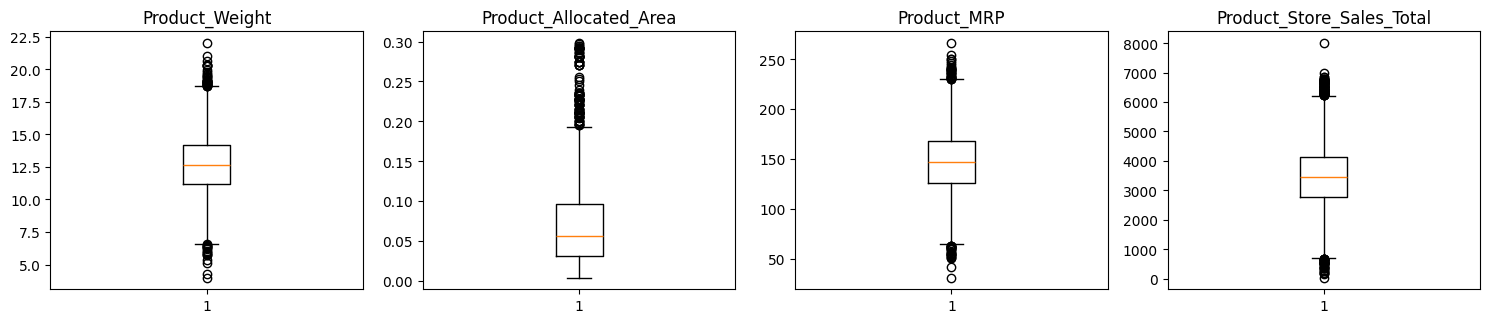

In [174]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [175]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Let's remove the columns that are not required.

In [176]:
data = data.drop(["Product_Id","Product_Type","Store_Id","Store_Establishment_Year"], axis=1, errors='ignore') #Complete the code to drop the columns "Product_Id","Product_Type","Store_Id","Store_Establishment_Year"

In [177]:
data.shape

(8763, 11)

In [178]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [180]:
X = data.drop("Product_Store_Sales_Total", axis=1) #Complete the code to drop the target variable
y = data["Product_Store_Sales_Total"] #Complete the code to select the target variable

In [181]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, shuffle=True #Complete the code to define the test_size
)

In [182]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

### **Data Pre-processing Pipeline**

In [183]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['Product_Sugar_Content',
 'Store_Size',
 'Store_Location_City_Type',
 'Store_Type',
 'Product_Id_char',
 'Product_Type_Category']

In [184]:
# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Define functions for Model Evaluation

In [185]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

## Decision Tree Model

In [250]:
# Initialize, pipeline, and fit the Decision Tree Regressor model
dtree = DecisionTreeRegressor(random_state=1)
dtree = make_pipeline(preprocessor,dtree)
dtree.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=1))])

### Checking model performance on training set

In [251]:
# Evaluate the Decision Tree Regressor model performance on the training dataset
dtree_model_train_perf = model_performance_regression(dtree, X_train, y_train)
dtree_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965498,0.685033,0.684519,0.16569


### Checking model performance on test set

In [252]:
# Evaluate the Decision Tree Regressor model performance on the testing dataset
dtree_model_test_perf = model_performance_regression(dtree, X_test, y_test)
dtree_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429583,0.668482,0.667215,0.187421


## Bagging Regressor

In [253]:
# Initialize, pipeline, and fit the Bagging Regressor model
bagging_regressor = BaggingRegressor(random_state=1)
bagging_regressor = make_pipeline(preprocessor,bagging_regressor)
bagging_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor', BaggingRegressor(random_state=1))])

### Checking model performance on training set

In [254]:
# Evaluate the Bagging Regressor model performance on the training dataset
bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
bagging_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.064588,469.426208,0.684942,0.684428,0.165799


### Checking model performance on test set

In [255]:
# Evaluate the Bagging Regressor model performance on the testing dataset
bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
bagging_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.866125,485.588892,0.668554,0.667288,0.18735


## Random Forest Model

In [256]:
# Initialize, pipeline, and fit the Random Forest Regressor model
rf_estimator = RandomForestRegressor(random_state=1)
rf_estimator = make_pipeline(preprocessor,rf_estimator)
rf_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=1))])

### Checking model performance on training set

In [257]:
# Evaluate the Random Forest Regressor model performance on the training dataset
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.994959,468.87585,0.685016,0.684501,0.165674


### Checking model performance on test set

In [258]:
# Evaluate the Random Forest Regressor model performance on the testing dataset
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.906846,485.311027,0.66851,0.667244,0.187394


## AdaBoost Regressor

In [259]:
# Initialize, pipeline, and fit the AdaBoost Regressor model
ab_regressor = AdaBoostRegressor(random_state=1)
ab_regressor = make_pipeline(preprocessor,ab_regressor)
ab_regressor.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor', AdaBoostRegressor(random_state=1))])

### Checking model performance on training set

In [260]:
# Evaluate the AdaBoost Regressor model performance on the training dataset
ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
ab_regressor_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,627.778405,512.191947,0.651694,0.651126,0.172981


### Checking model performance on test set

In [261]:
# Evaluate the AdaBoost Regressor model performance on the testing dataset
ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
ab_regressor_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,647.483018,530.557049,0.633649,0.63225,0.193723


## Gradient Boosting Regressor

In [262]:
# Initialize, pipeline, and fit the Gradient Boosting Regressor model
gb_estimator = GradientBoostingRegressor(random_state=1)
gb_estimator = make_pipeline(preprocessor,gb_estimator)
gb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(random_state=1))])

### Checking model performance on training set

In [263]:
# Evaluate the Gradient Boosting Regressor model performance on the training dataset
gb_estimator_model_train_perf = model_performance_regression(gb_estimator, X_train, y_train)
gb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.006101,469.061969,0.685004,0.684489,0.16573


### Checking model performance on test set

In [264]:
# Evaluate the Gradient Boosting Regressor model performance on the testing dataset
gb_estimator_model_test_perf = model_performance_regression(gb_estimator, X_test, y_test)
gb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.902369,485.444821,0.668515,0.667249,0.187447


## XGBoost Regressor

In [265]:
# Initialize, pipeline, and fit the XGBoost Regressor model
xgb_estimator = XGBRegressor(random_state=1)
xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
xgb_estimator.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Checking model performance on training set

In [266]:
# Evaluate the XGBoost Regressor model performance on the training dataset
xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
xgb_estimator_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,596.978222,468.965507,0.685033,0.684519,0.16569


### Checking model performance on test set

In [267]:
# Evaluate the XGBoost Regressor model performance on the testing dataset
xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
xgb_estimator_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.933034,485.429585,0.668482,0.667215,0.187421


# **Model Performance Improvement - Hyperparameter Tuning**

## Hyperparameter Tuning - Decision Tree

In [268]:
# Perform hyperparameter tuning on the Decision Tree Regressor using GridSearchCV
dtree_tuned = DecisionTreeRegressor(random_state=1)
dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

# Grid of parameters to choose from
parameters = {
    "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
    "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
    "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
    "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
}

# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=r2_score, cv=3, n_jobs =-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
dtree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=np.int64(2), max_leaf_nodes=2,
                                       min_impurity_decrease=0.001,
                                       random_state=1))])

### Checking model performance on training set

In [269]:
# Evaluate the tuned Decision Tree Regressor performance on the training dataset
dtree_tuned_model_train_perf = model_performance_regression(dtree_tuned, X_train, y_train)
dtree_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,830.838204,656.388225,0.389929,0.388932,0.214436


### Checking model performance on test set

In [270]:
# Evaluate the tuned Decision Tree Regressor performance on the testing dataset
dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
dtree_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,845.130586,668.489477,0.375851,0.373467,0.234787


## Hyperparameter Tuning - Bagging Regressor

In [271]:
# Perform hyperparameter tuning on the Bagging Regressor using GridSearchCV
bagging_estimator_tuned = BaggingRegressor(random_state=1)
bagging_estimator_tuned = make_pipeline(preprocessor,bagging_estimator_tuned)

# Grid of parameters to choose from
parameters = {
    "baggingregressor__max_samples": [0.7, 0.8, 0.9],
    "baggingregressor__max_features": [0.7, 0.8, 0.9],
    "baggingregressor__n_estimators": [50, 100, 150]
}

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('baggingregressor',
                 BaggingRegressor(max_features=0.7, max_samples=0.7,
                                  n_estimators=50, random_state=1))])

### Checking model performance on training set

In [272]:
# Evaluate the tuned Bagging Regressor performance on the training dataset
bagging_estimator_tuned_model_train_perf = model_performance_regression(bagging_estimator_tuned, X_train, y_train)
bagging_estimator_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.02421,469.397836,0.684985,0.68447,0.165752


In [273]:
# Evaluate the tuned Bagging Regressor performance on the testing dataset
bagging_estimator_tuned_model_test_perf = model_performance_regression(bagging_estimator_tuned, X_test, y_test)
bagging_estimator_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.843962,485.738203,0.668578,0.667312,0.187375


## Hyperparameter Tuning - Random Forest

In [210]:
rf_tuned = RandomForestRegressor(random_state=1)
rf_tuned = make_pipeline(preprocessor,rf_tuned)

# Grid of parameters to choose from
parameters = {
    "randomforestregressor__max_depth": [10, 20, 30], #Complete the code to define the list of values to be tuned
    "randomforestregressor__max_features":[0.7, 0.8, 0.9], #Complete the code to define the list of values to be tuned
    "randomforestregressor__n_estimators": [50, 100, 150], #Complete the code to define the list of values to be tuned
}

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=10, max_features=0.7,
                                       n_estimators=50, random_state=1))])

### Checking model performance on training set

In [211]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.013776,469.344374,0.684996,0.684481,0.165711


### Checking model performance on test set

In [212]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.87596,485.671288,0.668543,0.667277,0.187302


## Hyperparameter Tuning - AdaBoost Regressor

In [213]:
ab_tuned = AdaBoostRegressor(random_state=1)
ab_tuned = make_pipeline(preprocessor,ab_tuned)
# Grid of parameters to choose from
parameters = {
    "adaboostregressor__n_estimators": [50, 100, 150], #Complete the code to define the list of values to be tuned
    "adaboostregressor__learning_rate": [0.01, 0.1, 1], #Complete the code to define the list of values to be tuned
}


# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
ab_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('adaboostregressor',
                 AdaBoostRegressor(learning_rate=0.01, random_state=1))])

### Checking model performance on training set

In [214]:
ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
ab_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.816706,473.070121,0.684148,0.683632,0.166248


### Checking model performance on test set

In [274]:
# Evaluate the tuned AdaBoost Regressor performance on the testing dataset
ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
ab_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.740955,488.848774,0.668689,0.667423,0.187821


## Hyperparameter Tuning - Gradient Boosting Regressor

In [275]:
# Perform hyperparameter tuning on the Gradient Boosting Regressor using GridSearchCV
gb_tuned = GradientBoostingRegressor(random_state=1)
gb_tuned = make_pipeline(preprocessor,gb_tuned)

# Grid of parameters to choose from
parameters = {
    "gradientboostingregressor__n_estimators": [50, 100, 150],
    "gradientboostingregressor__subsample": [0.7, 0.8, 0.9],
    "gradientboostingregressor__max_features": [0.7, 0.8, 0.9],
    "gradientboostingregressor__max_depth": [3, 5, 7],
}

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_features=0.7, n_estimators=50,
                                           random_state=1, subsample=0.7))])

### Checking model performance on training set

In [276]:
# Evaluate the tuned Gradient Boosting Regressor performance on the training dataset
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.154637,469.005315,0.684847,0.684332,0.165814


### Checking model performance on test set

In [277]:
# Evaluate the tuned Gradient Boosting Regressor performance on the testing dataset
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.879945,485.144737,0.668539,0.667273,0.18752


## Hyperparameter Tuning - XGBoost Regressor

In [278]:
# Perform hyperparameter tuning on the XGBoost Regressor using GridSearchCV
xgb_tuned = XGBRegressor(random_state=1)
xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# Grid of parameters to choose from
parameters = {
    "xgbregressor__n_estimators": [50, 100, 150],
    "xgbregressor__subsample": [0.7, 0.8, 0.9],
    "xgbregressor__gamma": [0.1, 0.2, 0.3],
    "xgbregressor__colsample_bytree": [0.7, 0.8, 0.9],
    "xgbregressor__colsample_bylevel": [0.7, 0.8, 0.9],
}

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=50, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [220]:
if 'xgb_tuned' in locals():
    print('xgb_tuned is defined.')
else:
    print('xgb_tuned is not defined. Please run the training cell for xgb_tuned.')

xgb_tuned is defined.


### Checking model performance on training set

In [280]:
# Evaluate the tuned XGBoost Regressor performance on the training dataset
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,597.100682,469.036732,0.684904,0.684389,0.165657


### Checking model performance on test set

In [281]:
# Evaluate the tuned XGBoost Regressor performance on the testing dataset
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
xgb_tuned_model_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,615.578194,485.100796,0.668864,0.667599,0.187289


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [223]:
 # training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_estimator_model_train_perf.T,
        rf_tuned_model_train_perf.T,
        xgb_estimator_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_train_comp_df.columns = ["Random Forest", "Random Forest Tuned", "XGBoost", "XGBoost Tuned"]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,596.994959,597.013776,596.978222,597.100682
MAE,468.875850,469.344374,468.965507,469.036732
R-squared,0.685016,0.684996,0.685033,0.684904
Adj. R-squared,0.684501,0.684481,0.684519,0.684389
MAPE,0.165674,0.165711,0.165690,0.165657


In [224]:
 # testing performance comparison

models_test_comp_df = pd.concat(
    [
        rf_estimator_model_test_perf.T,
        rf_tuned_model_test_perf.T,
        xgb_estimator_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = ["Random Forest", "Random Forest Tuned", "XGBoost", "XGBoost Tuned"]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,615.906846,615.875960,615.933034,615.578194
MAE,485.311027,485.671288,485.429585,485.100796
R-squared,0.668510,0.668543,0.668482,0.668864
Adj. R-squared,0.667244,0.667277,0.667215,0.667599
MAPE,0.187394,0.187302,0.187421,0.187289


In [225]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [226]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/xgboost_model.joblib"

In [227]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/xgboost_model.joblib


In [228]:
import os
import joblib

# Ensure the target directory exists
os.makedirs('backend_files', exist_ok=True)

dest_path = 'backend_files/superkart_model.joblib'

# Safely look up the globally active model variables
global_vars = globals()
model_to_save = None

if 'saved_model' in global_vars:
    model_to_save = global_vars['saved_model']
    print("Found 'saved_model' in global namespace.")
elif 'xgb_tuned' in global_vars:
    model_to_save = global_vars['xgb_tuned']
    print("Found 'xgb_tuned' in global namespace.")
elif 'xgboost_model' in global_vars:
    model_to_save = global_vars['xgboost_model']
    print("Found 'xgboost_model' in global namespace.")

try:
    if model_to_save is not None:
        joblib.dump(model_to_save, dest_path)
        print(f"Successfully serialized model to {dest_path}")
    else:
        print("Error: No active model variable ('saved_model', 'xgb_tuned', or 'xgboost_model') found in globals to save.")
except Exception as e:
    print(f"Error saving model: {e}")

# Verify if the model file exists in the backend_files folder now
model_exists = os.path.exists(dest_path)
print(f"Does '{dest_path}' exist? {model_exists}")
if os.path.exists('backend_files'):
    print("Contents of 'backend_files':", os.listdir('backend_files'))

Found 'xgb_tuned' in global namespace.
Successfully serialized model to backend_files/superkart_model.joblib
Does 'backend_files/superkart_model.joblib' exist? True
Contents of 'backend_files': ['Dockerfile', 'superkart_model.joblib', 'xgboost_model.joblib', 'app.py', 'requirements.txt']


In [229]:
saved_model = joblib.load("backend_files/xgboost_model.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [230]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=50, n_jobs=None,
                              num_parallel_tree=None, ...))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [231]:
saved_model.predict(X_test)

array([3293.1404, 4902.711 , 4839.1284, ..., 3319.6055, 3293.1404,
       3293.1404], dtype=float32)

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [232]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [233]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("SuperKart")

# Load the trained model
model = joblib.load("superkart_model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart System"

# Define an endpoint to predict sales for a single product
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data
    sample = {
    'Product_Weight': data['Product_Weight'],
    'Product_Sugar_Content': data['Product_Sugar_Content'],
    'Product_Allocated_Area': data['Product_Allocated_Area'],
    'Product_MRP': data['Product_MRP'],
    'Store_Size': data['Store_Size'],
    'Store_Location_City_Type': data['Store_Location_City_Type'],
    'Store_Type': data['Store_Type'],
    'Product_Id_char': data['Product_Id_char'],
    'Store_Age_Years': data['Store_Age_Years'],
    'Product_Type_Category': data['Product_Type_Category']
}

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})

# Define an endpoint to predict sales for a batch of products
@superkart_api.post('/v1/predictbatch')
def predict_sales_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Create an output dictionary mapping row index to predicted sales
    output_dict = {str(i): round(pred, 2) for i, pred in enumerate(predictions)}

    return output_dict


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

In [234]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Overwriting backend_files/requirements.txt


## Dockerfile

In [235]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (assuming `app.py` contains the Flask instance named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Overwriting backend_files/Dockerfile


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [236]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [237]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import requests

# Base URL of the Flask backend
BACKEND_URL = "http://backend:7860"

# Page title
st.title("SuperKart System")
st.write(
    "Enter the product and store details below to predict the total sales."
)

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.027)
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store", "Food Mart"])
Product_Id_char = st.selectbox("Product ID Character", ["FD", "DR", "NC"])
Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, value=16)
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# Create JSON payload
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

# Single Prediction
if st.button("Predict", type='primary'):

    response = requests.post(
        f"{BACKEND_URL}/v1/predict",
        json=product_data
    )

    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.success(f"Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
    else:
        st.error("Unable to connect to the prediction API.")

# Batch Prediction
st.subheader("Batch Prediction")

uploaded_file = st.file_uploader(
    "Upload a CSV file",
    type=["csv"]
)

if uploaded_file is not None:

    if st.button("Predict for Batch", type='primary'):

        response = requests.post(
            f"{BACKEND_URL}/v1/predictbatch",
            files={"file": uploaded_file}
        )

        if response.status_code == 200:
            results = response.json()

            st.success("Predictions completed successfully!")

            try:
                if isinstance(results, list):
                    df = pd.DataFrame(results)
                elif isinstance(results, dict):
                    # Check if all values are scalars
                    if all(not isinstance(v, (list, dict)) for v in results.values()):
                        df = pd.DataFrame([results])
                    else:
                        df = pd.DataFrame(results)
                else:
                    df = pd.DataFrame({"Result": [results]})

                st.dataframe(df, use_container_width=True)

            except Exception as e:
                st.error(f"Unable to display results as a table: {e}")
                st.json(results)

        else:
            st.error("Unable to connect to the prediction API.")

Overwriting frontend_files/app.py


## Dependencies File

In [238]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


## Dockerfile

In [239]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

In [240]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')  # Complete the code to replace with the secret name for your token.For example, Gittoken

# After executing this code, you may be prompted to grant access. Click "Grant Access" to continue.

In [241]:
!pip install PyGithub

In [242]:
# Name for the new repository
REPO_NAME = "Superkart-sales-prediction-app"

# Authenticate with GitHub
from github import Github
from github import GithubException # Import for error handling

g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

repo = None
try:
    repo = user.get_repo(REPO_NAME)
    print(f"Repository '{REPO_NAME}' already exists. Using existing repository: {repo.html_url}")
except GithubException as e:
    if e.status == 404: # Not Found - means repo doesn't exist
        print(f"Repository '{REPO_NAME}' does not exist. Attempting to create it.")
        repo = user.create_repo(
            REPO_NAME,
            description="Superkart Sales Prediction App Backend and Frontend Deployment",
            private=False,
            auto_init=True
        )
        print(f"Repository created successfully: {repo.html_url}")
    else: # Other GitHub API errors
        print(f"An unexpected GitHub error occurred: {e}")
        raise # Re-raise if it's an unhandled error

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model.joblib": "backend_files/superkart_model.joblib",
    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    try:
        # Check if file exists in repo to decide between create and update
        existing_file = repo.get_contents(repo_path, ref="main")
        repo.update_file(
            path=repo_path,
            message=f"Update {repo_path}",
            content=content,
            sha=existing_file.sha, # Required for update
            branch="main"
        )
        print(f"Updated: {repo_path}")
    except GithubException as e:
        if e.status == 404: # File not found, so create it
            repo.create_file(
                path=repo_path,
                message=f"Add {repo_path}",
                content=content,
                branch="main"
            )
            print(f"Uploaded: {repo_path}")
        else: # Other GitHub API errors for file operations
            print(f"An unexpected GitHub error occurred while checking/creating/updating file {repo_path}: {e}")
            raise # Re-raise if it's an unhandled error

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: vazrala12345
Repository 'Superkart-sales-prediction-app' already exists. Using existing repository: https://github.com/vazrala12345/Superkart-sales-prediction-app
Updated: backend/app.py
Updated: backend/requirements.txt
Updated: backend/Dockerfile
Uploaded: backend/superkart_model.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile

All files pushed successfully to: https://github.com/vazrala12345/Superkart-sales-prediction-app


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [243]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [282]:
model_root_url = "https://redesigned-space-system-r475gg6vpj763wxr6-7860.app.github.dev/"  # Complete the code to replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [283]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [284]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [285]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [286]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [287]:
# Send the POST request to ensure 'response' is defined, then display it
response = requests.post(model_url, json=payload)
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [288]:
print(response.json())

{'Sales': -164.25074768066406}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [289]:
batch_dataset = pd.read_csv('/content/drive/MyDrive/Superkart/Batch_Data_SuperKart.csv')
display(batch_dataset.head())

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables


**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [290]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [291]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [292]:
response

<Response [200]>

In [293]:
# Extract predictions from API response
response.text

'{"0":-1256.45,"1":-193.66,"2":807.81,"3":-1573.49,"4":-98.95,"5":1232.02,"6":-1534.97,"7":-161.45,"8":1411.54,"9":-1463.34}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

-

-